## Overview
In a case where we have discrete tau values, we would expect some bandlimit based on the resolution and duration of the signal we have.

If we consider the Nyquist frequency

$$f_{\text{Nyq}} = \frac{1}{2}f_{\text{sample}}$$

we can calculate the highest frequency we can reconstruct for a finite bandwidth signal (finite bandwidth meaning there is a max and minimum frequency we would need to use to completely reconstruct the real signal). 

Using this idea, we can arrive at cutoff lifetimes for our signal (though, what the physical meaning of this is, I don't quite know - e^x is not a periodic function). Based off these estimates, I would calculate 

$$\tau_{\text{min}} = \frac{1}{2 \pi f_{\text{Nyq}}} = \frac{1}{\pi f_{\text{sample}}} = \frac{1}{\pi} \Delta t_{\text{min}}$$

$$\tau_{\text{max}} = \frac{1}{2\pi} T$$

where $T$ is the duration of the observation window, and $ \Delta t_{\text{min}}$ is the smallest observed time increment. 

In the following, I'll use the smallest observable tau option, and will cut off all lifetimes in the last decade

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [2]:
# Path to data
path = '../DRT IS Inductive Behaviour in Spectrum/tj.dat'

In [3]:
# Load Data
data = pd.read_csv(path, sep=r'\s+')

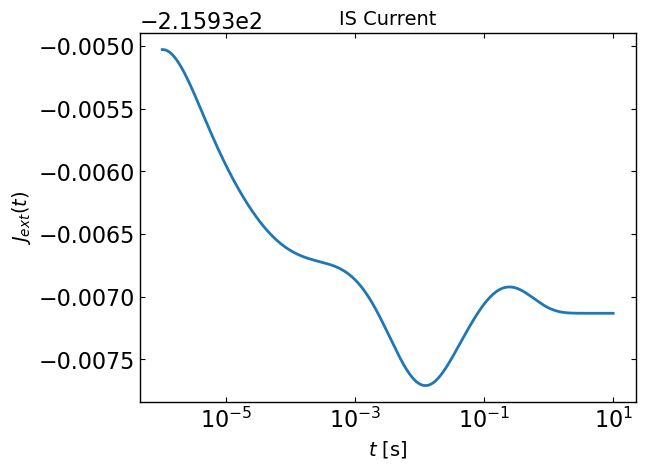

In [4]:
# Find where in the current density curve we see decay lifetimes 
start_index = 155
end_index = -1 #870
time = data['t'].iloc[start_index:end_index].values
current = data['Jext'].iloc[start_index:end_index].values

# Plot the Current Density
plt.plot(time, current)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$')
plt.title("IS Current")
plt.show()


In [5]:
# Define the tau grid to use for linear fits 

# Calculate the number of decades and points per decade (ppd) in the time array
time_decades = np.log10(time[-1]/time[0])
time_ppd = int(len(time) / time_decades)

# Define the tau values as a relative multiple of ppd
relative_resolution = 1 
tau_values = np.geomspace(time[0], time[-1], relative_resolution*len(time))

In [6]:
# Apply min-max scaling to the data 
current_scaled = (current - current.min())/(current.max() - current.min())

### Test 1 - Fit and then trim tau

In this test, I will: 

1. Checkerboard fit for tau values equal to time values 
2. Trim the last decade of tau values
3. Recalculate the MSE for curves constructed from the trimmed tau values

In [7]:
# Try the same again but with the checkerboard fit
checkerboard_fits = drt.checkerboard_fit(time, current_scaled, time, max_fit_iter=200)

In [8]:
# Plot all the DRT Curves
# i = 1
# for fit in checkerboard_fits: 
#     plt.plot(time, fit.U, linestyle='-.')
#     plt.xscale('log')
#     plt.xlabel("$\\tau$ [$\\text{s}$]")
#     plt.ylabel("$U$")
#     plt.xscale('log')
#     plt.title(f"Distribution of Relaxation Times after iteration: {i}")
#     plt.show()

#     i += 1

In [9]:
# For each fit, curtail the tau values and re-calculate MSE
trimmed_fits = []
trimmed_fits_MSE = []

for fit in checkerboard_fits:
    # Remove the last decade from the fit results
    new_U = fit.U[:-time_ppd]
    new_tau = fit.tau[:-time_ppd]
    new_m = fit.m - time_ppd

    new_fit = drt.DRT_Fit_Result(new_U, new_tau, fit.offset, None, new_m)

    new_fit.predict_y(time)
    new_fit.cost = np.mean((new_fit.y - current_scaled)**2)
    trimmed_fits.append(new_fit)
    trimmed_fits_MSE.append(new_fit.cost)

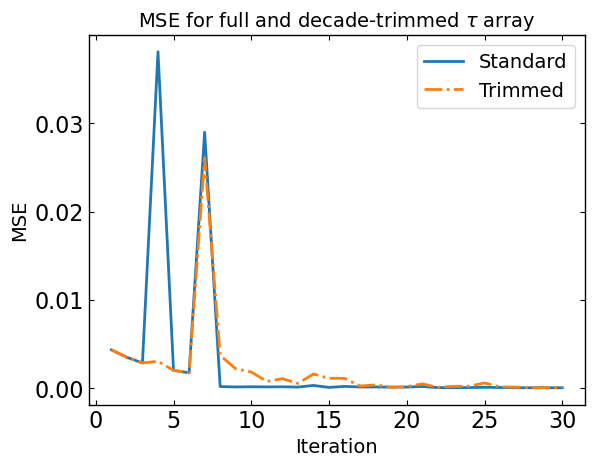

In [10]:
# Calcualte the MSE for curves with all tau values 
MSE = [np.mean((fit.y - current_scaled)**2) for fit in checkerboard_fits]

plt.plot(range(1, len(checkerboard_fits)+1), MSE, label='Standard')
plt.plot(range(1, len(checkerboard_fits)+1), trimmed_fits_MSE, linestyle = '-.', label='Trimmed')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title("MSE for full and decade-trimmed $\\tau$ array ")
plt.legend()
plt.show()

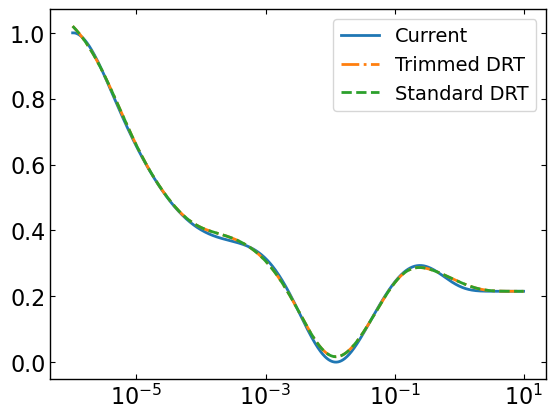

In [11]:
# Compare minimum MSE plots in both cases
trimmed_fit_min_MSE = trimmed_fits[np.argmin(trimmed_fits_MSE)]
standard_fit_min_MSE = checkerboard_fits[np.argmin(MSE)]

# Plot fitted curves 
plt.plot(time, current_scaled, label='Current')
plt.plot(time, trimmed_fit_min_MSE.y, label='Trimmed DRT', linestyle='-.')
plt.plot(time, standard_fit_min_MSE.y, label='Standard DRT', linestyle='--')
plt.xscale('log')
plt.legend()
plt.show()


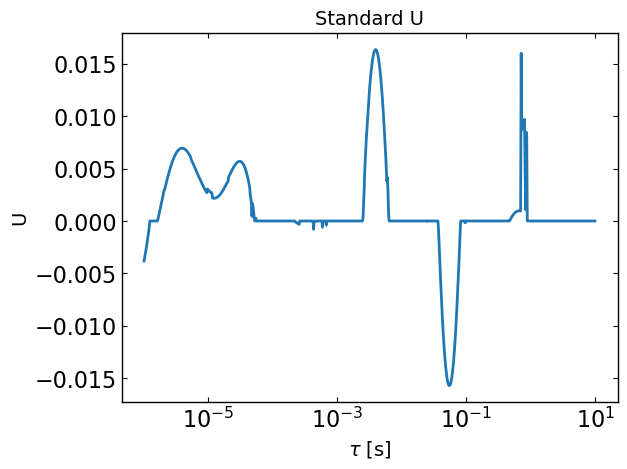

In [12]:
plt.plot(standard_fit_min_MSE.tau, standard_fit_min_MSE.U)
plt.xlabel("$\\tau$ [s]")
plt.ylabel("U")
plt.xscale('log')
plt.title("Standard U")
plt.show()

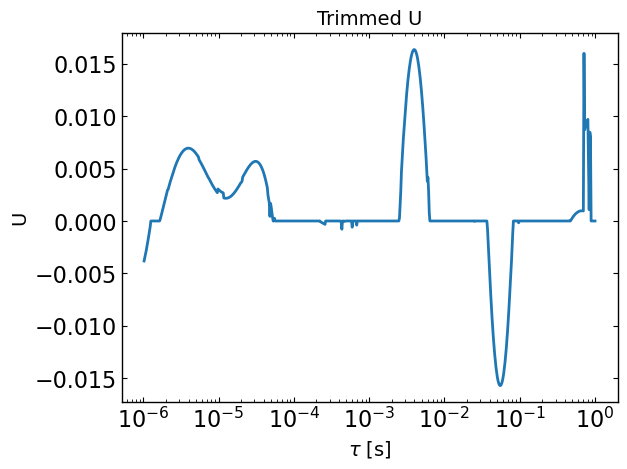

In [13]:
plt.plot(trimmed_fit_min_MSE.tau, trimmed_fit_min_MSE.U)
plt.xlabel("$\\tau$ [s]")
plt.ylabel("U")
plt.xscale('log')
plt.title("Trimmed U")
plt.show()

For whatever reason, the actually fit itself doesn't seem that good. I've put the code from commit 8399826dde87f6de70b6585174b2f4416842189c down below, which seems to be the last version of the code we were getting good fits for for testing purposes

In [14]:
"""Find System Lifetimes using Distribution of Relaxation Times (DRT) Fitting in the Time Domain"""
######### Package Imports #########################################################################

import matplotlib.pyplot as plt
# from pySIMsalabim.utils import device_parameters as utils_dev
import scipy.optimize as so
import numpy as np
import torch

######### References ##############################################################################

# [1] M. Schönleber, D. Klotz, and E. Ivers-Tiffée, ‘A Method for Improving the Robustness of linear 
# Kramers-Kronig Validity Tests’, Electrochimica Acta, vol. 131, pp. 20–27, June 2014, 
# doi: 10.1016/j.electacta.2014.01.034.

######### Class Definitions #######################################################################

class DRT_Fit_Result:
    """ A class that bundles together all results from fitting a DRT_curve curve to data

    Attributes
    ----------
    U : numpy.ndarray, shape (m,)
        Fitted coefficients [U_1, U_2, ..., U_m]
    tau : numpy.ndarray, shape (m,)
        Fitted lifetimes [tau_1, tau_2, ..., tau_m]
    offset : numpy.float64
        Fitted value for offset
    cost : numpy.float64
        The value of the cost function 
            F(x) = 0.5 * sum(rho(error_i(x)**2), i = 0, ..., n - 1)
        at the solution. By default, rho(z) = z. See scipy.optimize.least_squares for details
    m : int
        Number of lifetimes/coefficients used in DRT_curve, given by the length of U/tau
    
    Methods
    -------
    set_DRT_curve(t)
        Calculates DRT_curve(t) using the object's attributes (self.U, self.tau, self.offset)
        and sets self.DRT_curve equal to the result 
    """
    def __init__(self, U, tau, offset, cost, m):
        self.U = U
        self.tau = tau 
        self.offset = offset 
        self.cost = cost
        self.m = m 
        self.DRT_curve = None

    def set_DRT_curve(self, t, backend='numpy', device=torch.device('cpu')):
        """ Sets self.DRT_curve = DRT_curve(t) using the objects attributes

        Parameters
        ----------
        t : float or list/numpy.ndarray, shape (n,)
            Time values to calculate the DRT_curve curve
        backend : {'numpy', 'torch'} (optional)
            Determines whether matrix operations are done with numpy or pytorch. Default numpy. 
        device : torch.device (optional)
            Determines what device is used for matrix ops if backend='torch'.
        
        Returns
        -------
        None
        """
        self.DRT_curve = DRT_curve(t, self.U, self.tau, self.offset, backend=backend, device=device)


class DRTLinearModel(torch.nn.Module):
    def __init__(self, tau, U_scale_factor=1, offset=0, bounds=None, device=torch.device('cpu')):
        super().__init__()
        self.device = device
        self.tau = torch.tensor(tau, device=self.device, dtype=torch.float32)
        self.m = len(tau)
        
        # Define the parameters object, which will hold U and tau
        self.params = torch.nn.Parameter(torch.concat((torch.ones(self.m, device=device, dtype=torch.float32)/self.m*U_scale_factor, 
                                                       torch.tensor([offset], device=device, dtype=torch.float32))))
        
        # Set bounds for U values if given 
        if bounds is not None:
            self.lower_bound = bounds[0]
            self.upper_bound = bounds[1]
        else:
            self.lower_bound = None
            self.upper_bound = None
        
    def forward(self, t):
        if self.lower_bound is not None:
            params_clamped = torch.clamp(self.params, self.lower_bound, self.upper_bound)
        else:
            params_clamped = self.params
        return DRT_curve_pytorch(t, params_clamped[:-1], self.tau, params_clamped[-1])


######### Function Definitions ####################################################################

# Utility Functions #####################################
def numpy_converter(x):
    """Makes sure arraylike object is a numpy ndarray

    Parameters
    ----------
    x : arraylike 
    
    Returns
    -------
    x : np.ndarray

    """
    if isinstance(x, np.ndarray):
        x = x
    elif isinstance(x, list):
        x = np.array(x)
    elif isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    else:
        raise TypeError("Argument is not of type np.array, list, or torch.Tensor")
    return x
    
def torch_tensor_converter(x, device=torch.device('cpu')):
    """Makes sure arraylike object is a torch.Tensor

    Parameters
    ----------
    x : arraylike 
    
    Returns
    -------
    x : torch.Tensor on specified devicee

    """
    # Check if the device being used is an accelerator, and downcast floats if so
    if isinstance(x, torch.Tensor):
        x = x.to(torch.float32).to(device)
    elif isinstance(x, np.ndarray):
        x = torch.from_numpy(x).to(torch.float32).to(device)
    elif isinstance(x, list):
        x = torch.tensor(x, dtype=torch.float32, device=device)
    else:
        raise TypeError("Argument is not of type np.array, list, or torch.Tensor")
    return x

# Regularisation Functions ##############################
    
def IC_ratio_reg(U, alpha=0.01, backend='numpy', device=torch.device('cpu')):
    # Regularisation parameter inspired by the mu criterion in [1]
    if backend == 'numpy':
        U = numpy_converter(U)
        return alpha*(np.absolute(U[np.where(U < 0)]).sum() / np.absolute(U[np.where(U >= 0)]).sum())
    elif backend == 'torch':
        U = torch_tensor_converter(U, device=device)
        return alpha*(torch.absolute(U[torch.where(U < 0)]).sum() / torch.absolute(U[torch.where(U >= 0)]).sum())

def ridge_reg(x, alpha=0.01):
    x = numpy_converter(x)
    return alpha*np.square(x)

def lasso_reg(x, alpha=0.01):
    x = numpy_converter(x)
    return 
#########################################################

def DRT_curve_numpy(t, U, tau, offset=0):
    """Use numpy.ndarray objects to calculate the function 
        DRT_curve(t) = U_1*exp(-t/tau_1) + U_2*exp(-t/tau_2) + ... + U_m*exp(-t/tau_m) + offset
    
    Parameters
    ----------
    t : numpy.ndarray, shape (n,)
        The time values over which the simulated impedance-adjacent experiment takes place
    U : numpy.ndarray with shape (m,)
        Coefficients for the exponential decay functions such that U[i] is the coefficient of 
        exp(-t/tau[i])
    tau : numpy.ndarray with shape (m,)
        The distribution of relaxation times
    offset : float (optional)
        Initial guess of the DRT_curve offset value
    device : torch.device 
        The specified device for torch based computation if backend='torch'. 
    
    Returns 
    -------
    calculated_DRT_curve : numpy.ndarray with shape (n,)
        DRT_curve at all time values in t
    """
    # Calculate DRT_curve(t) for all values in t
    calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset

    return calculated_DRT_curve


def DRT_curve_pytorch(t, U, tau, offset=0):
    """Use torch.Tensor objects to calculate the function
        DRT_curve(t) = U_1*exp(-t/tau_1) + U_2*exp(-t/tau_2) + ... + U_m*exp(-t/tau_m) + offset
    
    Parameters
    ----------
    t : torch.Tensor, shape (n,)
        The time values over which the simulated impedance-adjacent experiment takes place
    U : torch.Tensor, shape (m,)
        Coefficients for the exponential decay functions such that U[i] is the coefficient of 
        exp(-t/tau[i])
    tau : torch.Tensor with shape (m,)
        The distribution of relaxation times
    offset : float (optional)
        Initial guess of the DRT_curve offset value
    
    Returns 
    -------
    calculated_DRT_curve : torch.Tensor with shape (n,)
        DRT_curve at all time values in t
    """

    # Calculate DRT_curve(t) for all values in t
    calculated_DRT_curve = (U @ torch.exp(-torch.outer(1/tau, t))) + offset
    
    return calculated_DRT_curve


def DRT_curve(t, U, tau, offset=0, backend='numpy', device=torch.device('cpu')):
    """Calculate the function
        DRT_curve(t) = U_1*exp(-t/tau_1) + U_2*exp(-t/tau_2) + ... + U_m*exp(-t/tau_m) + offset
    
    Parameters
    ----------
    t : array-like, shape (n,)
        The time values over which the simulated impedance-adjacent experiment takes place
    U : array-like, shape (m,)
        Coefficients for the exponential decay functions such that U[i] is the coefficient of 
        exp(-t/tau[i])
    tau : array-like with shape (m,)
        The distribution of relaxation times
    offset : float (optional)
        Initial guess of the DRT_curve offset value
    backend : {'numpy', 'torch'} (optional)
        Determines whether matrix operations are done with numpy or pytorch. Default numpy. 
    device : torch.device (optional)
        Determines what device is used for matrix ops if backend='torch'.
    
    Returns 
    -------
    calculated_DRT_curve : numpy.ndarray or torch.Tensor with shape (n,)
        DRT_curve at all time values in t
    """
    
    if backend == 'numpy':
        t = numpy_converter(t)
        U = numpy_converter(U)
        tau = numpy_converter(tau)

        return DRT_curve_numpy(t, U, tau, offset=offset)

    elif backend == 'torch':
        t = torch_tensor_converter(t, device=device)
        U = torch_tensor_converter(U, device=device)
        tau = torch_tensor_converter(tau, device=device)

        return DRT_curve_pytorch(t, U, tau, offset)


def fit_DRT_curve(t, y, U0, tau0, offset0=0, set_DRT_curve=True, **kwargs):
    """Fits an DRT_curve(t) curve to a function y(t)

    Uses a non-linear approach to fit 
        DRT_curve(t) = U_1*exp(-t/tau_1) + U_2*exp(-t/tau_2) + ... + U_m*exp(-t/tau_m) + offset
    to a function y by finding the optimal values for the parameters 
        U = [U_1, U_2, ..., U_m] 
        tau = [tau_1, tau_2, ..., tau_m]
        
    Parameters
    ----------
    t : (list/numpy.ndarray) with shape (n,)
        The time values over which the function y is known
    y : list/numpy.ndarray with shape (n,)
        The values of y(t) that DRT_curve will be fitted to
    U0 : list/numpy.ndarray with shape (m,)
        Initial guess of U values for fitting 
    tau0 : list/numpy.ndarray with shape (m,)
        Initial guess of tau values for fitting
    offset0 : float (optional)
        Initial guess of the DRT_curve offset value
    set_DRT_curve : bool (optional)
        If true, will set the DRT_curve attribute of the returned DRT_Fit_Result object using t
    kwargs
        Keyword arguments passed to scipy.optimize.least_squares for fitting
    
    Returns
    -------
    drt_fit : DRT_Fit_Result 
        With attributes as follows
            U : numpy.ndarray, shape (m,)
                Fitted [U_1, U_2, ..., U_m] array
            tau : numpy.ndarray, shape (m, )
                Fitted [tau_1, tau_2, ..., tau_m] array
            offset : numpy.float64
                Fitted value for offset
            cost : numpy.float64
                The value of the cost function 
                    F(x) = 0.5 * sum(rho(error_i(x)**2), i = 0, ..., n - 1)
                at the solution. By default, rho(z) = z. See scipy.optimize.least_squares for details
            m : int
                Number of lifetimes/coefficients used in DRT_curve, given by the length of U/tau
    """
    
    # Make sure passed parameters are numpy.ndarrays
    t = np.array(t)
    y = np.array(y)
    U0 = np.array(U0)
    tau0 = np.array(tau0)
    m = len(U0)
    
    # Create an initial parameter array to pass to the fitting algorithm
    initial_params = np.concatenate((U0, tau0, [offset0]))
    
    # Create the error function 
    error = lambda x : y - DRT_curve(t, x[:m], x[m:-1], offset=x[-1])
    
    # Fit the params using scipy. Note x_scale='jac' makes for better fits than the default value
    fit = so.least_squares(error, x0=initial_params, x_scale='jac', **kwargs)
    
    # Store the fit results
    drt_fit = DRT_Fit_Result(fit.x[:m], fit.x[m:-1], fit.x[-1], fit.cost, m)

    # Set the DRT_curve curves for each DRT_Fit_Result result if calc_DRT_curve=True
    drt_fit.set_DRT_curve(t) if set_DRT_curve else None
    
    return drt_fit


def multi_fit_DRT_curve(t, y, m_values, U_scale_factor=0, offset0=0, set_DRT_curve=True, **kwargs):
    """ Runs fit_DRT_curve over multiple m values 
    
    Parameters
    ----------
    t : list or numpy.ndarray, shape (n,)
        Time values over which y(t) is known
    y : list or numpy.ndarray, shape(n, )
        y(t) values each DRT_curve curve is fitted to
    m_values : list, shape (i,)
        Various m values for fit_DRT_curve, where m is the number of coefficients/lifetimes
        in DRT_curve(t)
    U_scale_factor : float
        Controls the scale for the intial guess of the coefficients U0 passed to fit_DRT_curve
    offset0 : float 
        Initial guess for the offset passed to fit_DRT_curve
    set_DRT_curve : bool (optional)
        If true, will set the DRT_curve attribute of the returned DRT_Fit_Result objects using t
    kwargs 
        Keyword arguments passed to scipy.optimize.least_squares for fitting

    Returns
    -------
    fits : list of DRT_Fit_Result, shape (i,)
        List of DRT_Fit_Result objects, one for each passed m value
    """
    fits = []
    
    # Fit the params for each m
    for m in m_values:
        # Default estimate U, tau, and offset 
        U0 = np.ones(m)*U_scale_factor/m
        tau0 = np.geomspace(t[0], t[-1], m)
        offset0 = offset0
        
        # Fit the curve
        fit = fit_DRT_curve(t, y, U0, tau0, offset0=offset0, set_DRT_curve=set_DRT_curve, **kwargs)
        
        # Add to fits
        fits.append(fit)
        
    return fits


def fit_DRT_curve_linear(t, y, tau, U_scale_factor=1, offset=0, alpha=0, set_DRT_curve=True, backend='numpy', device='cpu', **kwargs):
    """Fits an DRT_curve(t) curve to a function y(t) using a grid-based approach

        Uses a linear approach to fit 
            DRT_curve(t) = U_1*exp(-t/tau_1) + U_2*exp(-t/tau_2) + ... + U_m*exp(-t/tau_m) + offset
        to a function y by finding the optimal values for the parameters 
            U = [U_1, U_2, ..., U_m] 
            tau = [tau_1, tau_2, ..., tau_m]
            
        Parameters
        ----------
        t : (list/numpy.ndarray) with shape (n,)
            The time values over which the function y is known
        y : list/numpy.ndarray with shape (n,)
            The values of y(t) that DRT_curve will be fitted to
        tau : list/numpy.ndarray with shape (m,)
            Grid of tau values used in calculating DRT_curve(t)
        U_scale_factor : float
            Determines the magnitude and polarity of initial guess for U
        offset0 : float (optional)
            Initial guess of the DRT_curve offset value
        set_DRT_curve : bool (optional)
            If true, will set the DRT_curve attribute of the returned DRT_Fit_Result object using t
        backend : {'numpy', 'torch'} (optional)
            Determines whether matrix operations are done with numpy or pytorch. Default numpy. 
        device : {'cpu', 'acc', torch.device} (optional)
            Determines what device is used for matrix ops if backend='torch'. 'cpu' runs all calculations
            on the CPU and 'acc' will run calculations on a accelerator (cuda, mps, etc) if available.
            Any passed torch.device object will be used.
        kwargs
            Keyword arguments passed to scipy.optimize.least_squares for fitting
        
        Returns
        -------
        drt_fit : DRT_Fit_Result 
            With attributes as follows
                U : numpy.ndarray or torch.Tensor, shape (m,)
                    Fitted [U_1, U_2, ..., U_m] array
                tau : numpy.ndarray or torch.Tensor, shape (m, )
                    Fitted [tau_1, tau_2, ..., tau_m] array
                offset : numpy.float64
                    Fitted value for offset
                cost : numpy.float64
                    The value of the cost function 
                        F(x) = 0.5 * sum(rho(error_i(x)**2), i = 0, ..., n - 1)
                    at the solution. By default, rho(z) = z. See scipy.optimize.least_squares for details
                m : int
                    Number of lifetimes/coefficients used in DRT_curve, given by the length of U/tau
        """
    # Create the error function 
    if backend == 'numpy':
        # Make sure passed parameters are numpy.ndarrays
        t = numpy_converter(t)
        y = numpy_converter(y)
        tau = numpy_converter(tau)

        # Create initial guess for U 
        m = len(tau)
        U0 = U_scale_factor*np.ones(m)/m

        # Create an initial array-like guess of variables
        x0 = np.concatenate((U0, [offset]))

        # Define the error function
        error = lambda x : y - DRT_curve(t, x[:-1], tau, offset=x[-1], backend='numpy')
        
        # Minimise the error function using scipy
        fit = so.least_squares(error, x0=x0, **kwargs)

        # Store the results in a DRT_Fit object
        drt_fit = DRT_Fit_Result(fit.x[:-1], tau, fit.x[-1], fit.cost, m)

        # Set the DRT_curve curve for DRT_Fit_Result result if calc_DRT_curve=True
        drt_fit.set_DRT_curve(t) if set_DRT_curve else None

        # Assume params is of dimension 2 x m, where m is the number of tau/U_values
        return drt_fit

    elif backend == 'torch':
        # Check which device should be used for calculations 
        if device == 'cpu': 
            device = torch.device('cpu')
        elif device == 'acc':
            if torch.accelerator.is_available(): 
                device = torch.accelerator.current_accelerator() 
            else:
                raise Exception("Accelerator unavailable")
        elif isinstance(device, torch.device):
            device = device
        else:
            raise Exception("Device needs to be 'cpu', 'acc', or of type torch.device")

        # Make sure passed parameters are torch.Tensor objects
        t = torch_tensor_converter(t, device=device)
        y = torch_tensor_converter(y, device=device)
        tau = torch_tensor_converter(tau, device=device)
        
        # Create initial guess for U 
        m = tau.size(dim=0)
        U0 = U_scale_factor*torch.ones(m, device=device)/m

        # Create an initial array-like guess of variables
        x0 = torch.cat((U0, torch.tensor([offset], device=device, dtype=torch.float32)))

        error = lambda x : y - DRT_curve(t, x[:-1], tau, offset=x[-1], backend='torch', device=device)

        # Minimise the error function using scipy
        fit = so.least_squares(error, x0=x0, **kwargs)

        # Store the results in a DRT_Fit object
        drt_fit = DRT_Fit_Result(fit.x[:-1], tau, fit.x[-1], fit.cost, m)

        # Set the DRT_curve curve for DRT_Fit_Result result if calc_DRT_curve=True
        drt_fit.set_DRT_curve(t) if set_DRT_curve else None

        # Assume params is of dimension 2 x m, where m is the number of tau/U_values
        return drt_fit
        
        
def fit_DRT_curve_linear_torch(t, y, tau, U_scale_factor='Auto', offset='Auto', set_DRT_curve=True, alpha=0, max_step_iter=20, max_iter=200, device='cpu', bounds=None, **kwargs):
    
    # Get the device type
    if device == 'cpu': 
            device = torch.device('cpu')
    elif device == 'acc':
        if torch.accelerator.is_available(): 
            device = torch.accelerator.current_accelerator() 
        else:
            raise Exception("Accelerator unavailable")
    elif isinstance(device, torch.device):
        device = device
    else:
        raise Exception("Device needs to be 'cpu', 'acc', or of type torch.device")
    
    # Set U scale factor 
    if U_scale_factor == 'Auto':
        U_scale_factor = np.max(y) - np.min(y)
    else: 
        U_scale_factor = U_scale_factor
    
    # Set offset
    if offset == 'Auto':
        offset = np.min(y)
    else: 
        offset = offset
        
    # Convert input into tensors 
    t = torch_tensor_converter(t, device=device)
    y = torch_tensor_converter(y, device=device)
    
    # Construct the pytorch model
    linear_model = DRTLinearModel(tau, U_scale_factor=U_scale_factor, offset=offset, bounds=bounds, device=device)
    
    # Define an optimizer 
    optimizer = torch.optim.LBFGS(linear_model.parameters(), max_iter=max_step_iter, history_size=10)
    
    # Loss History
    loss_history = []
    
    def closure():
        optimizer.zero_grad()
        predictions = linear_model(t)
                
        # Define loss using our IC regulariser 
        loss = torch.sum((predictions - y)**2) + alpha*IC_ratio_reg(linear_model.params[:-1], alpha=alpha, backend='torch', device=device)
        
        loss.backward()
        loss_history.append(loss.item())
        return loss
    
    for epoch in range(max_iter // max_step_iter):
        optimizer.step(closure)
        if bounds:
            for param in linear_model.parameters():
                param.data.clamp_(bounds[0], bounds[1])
        
        if len(loss_history) > 1:
            if abs(loss_history[-1] - loss_history[-2]) < 1e-9:
                break
    
    # Return results 
    final_loss = loss_history[-1]
    final_params = linear_model.params.detach().cpu().numpy()
    U = final_params[:-1]
    offset = final_params[-1]
    
    final_fit_result = DRT_Fit_Result(U, tau, offset, final_loss, m=len(tau))
    
    if set_DRT_curve:
        final_fit_result.set_DRT_curve(t)
    
    return final_fit_result


def fit_DRT_curve_checkerboard(t, y, tau, alpha=0, max_step_iter=20, max_iter=200, device='cpu', **kwargs):
    
    max_iters = 30
    offset = y[-1]
    U_values = np.zeros(len(tau))
    
    y_cap = y

    cap_U_values = np.zeros(len(tau))
    ind_U_values = np.zeros(len(tau))

    cap_offset = offset
    ind_offset = 0

    fits = []
    
    MSE = []
    cost = []
    
    # NOTE: we probably want to set the offset and scale factor guesses ourselves
    for i in range(max_iters):
        
        # Set scale params for capacitive effects and fit
        cap_fit = fit_DRT_curve_linear_torch(t, y_cap, tau, device=device, offset=cap_offset, alpha=alpha, 
                                       max_step_iter=max_step_iter, max_iter=max_iter, bounds=(0, np.inf), **kwargs)
        
        # Add the fit to U_values
        cap_U_values = cap_fit.U
        
        # Remove the capacitive effects from y
        y_ind = y - cap_fit.DRT_curve
        ind_offset = y_ind[-1]
        
        # Set the inductive scale params and fit by doing a capacitive fit on an inverted function
        ind_fit = fit_DRT_curve_linear_torch(t, -y_ind, tau, device=device, offset=-ind_offset, alpha=alpha, 
                                       max_step_iter=max_step_iter, max_iter=max_iter, bounds=(0, np.inf), **kwargs)
        
        # Add the fit to U_values 
        ind_U_values = -ind_fit.U

        # Remove the inductive effects from the curve for the next iteration
        y_cap = y + ind_fit.DRT_curve
        cap_offset = y_cap[-1]
        
        # Once the fit is done, return a fit object with the results and a dummy cost of 0
        U_values = cap_U_values + ind_U_values
        fit = DRT_Fit_Result(U_values, tau, offset, 0, len(tau))
        
        # Calculate the cost 
        fit.set_DRT_curve(t)
        MSE.append(np.mean((y-fit.DRT_curve)**2))
        cost.append(np.sum((fit.DRT_curve - y)**2) + alpha*IC_ratio_reg(fit.U, alpha=alpha, backend='torch', device=device))
        fits.append(fit)
        
        plt.plot(t, y, label='Sim')
        plt.plot(t, cap_fit.DRT_curve, linestyle='-.', label='cap')
        plt.plot(t, -ind_fit.DRT_curve, linestyle=':', label='ind')
        plt.xscale('log')
        plt.xlabel("$t$ [$\\text{s}$]")
        plt.ylabel("$J$")
        plt.xscale('log')
        plt.title(f"Perfect Impedance Curve {i}")
        plt.legend()
        plt.show()
        
        plt.plot(tau, cap_U_values, label='Cap', linestyle='-.')
        plt.plot(tau, -ind_U_values, label='ind', linestyle=':')
        plt.xscale('log')
        plt.xlabel("$\\tau$ [$\\text{s}$]")
        plt.ylabel("$U$")
        plt.xscale('log')
        plt.title(f"Distribution of Relaxation Times {i}")
        plt.show()
        
        plt.plot(t, y - cap_fit.DRT_curve, linestyle='-.', label='cap')
        plt.xscale('log')
        plt.xlabel("$t$ [$\\text{s}$]")
        plt.ylabel("Residual $J - \hat{J}_{\\text{cap}}$")
        plt.xscale('log')
        plt.title(f"Residuals post capacitive fit{i}")
        plt.legend()
        plt.show()
    
    plt.plot(range(max_iters), MSE)
    min_mse_index = np.argmin(MSE)
    plt.axvline(min_mse_index, label=f"index: {min_mse_index}")
    plt.xlabel("Iteration")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()
    
    plt.plot(range(max_iters), cost)
    min_cost_index = np.argmin(cost)
    plt.axvline(min_cost_index)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()
    
    return fits

<>:646: SyntaxWarning: invalid escape sequence '\h'
<>:646: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_8597/2965016613.py:646: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("Residual $J - \hat{J}_{\\text{cap}}$")


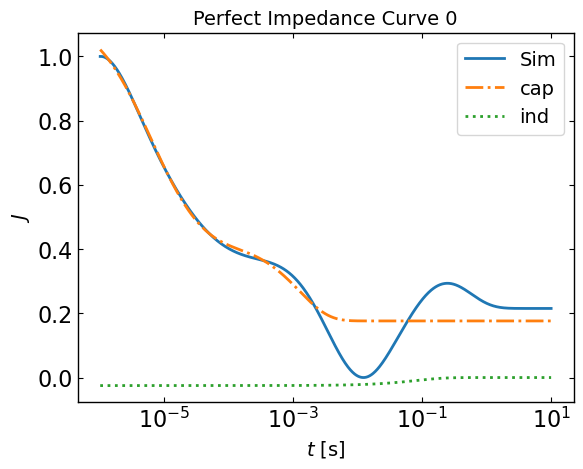

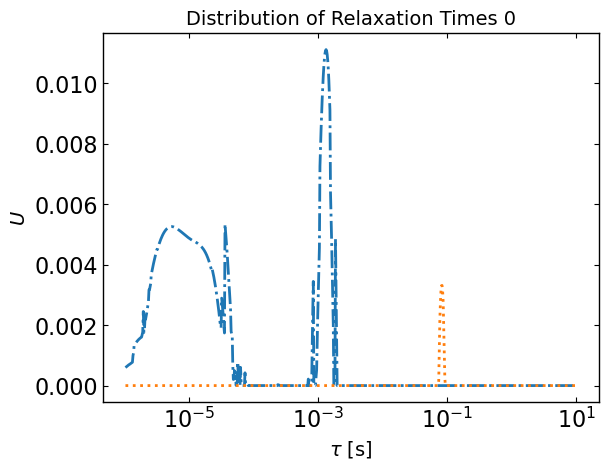

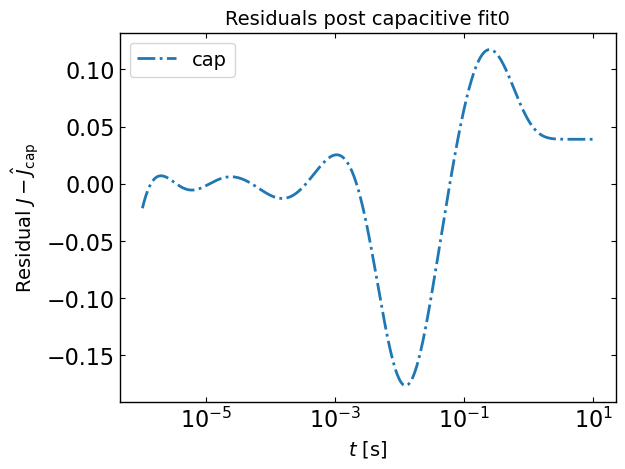

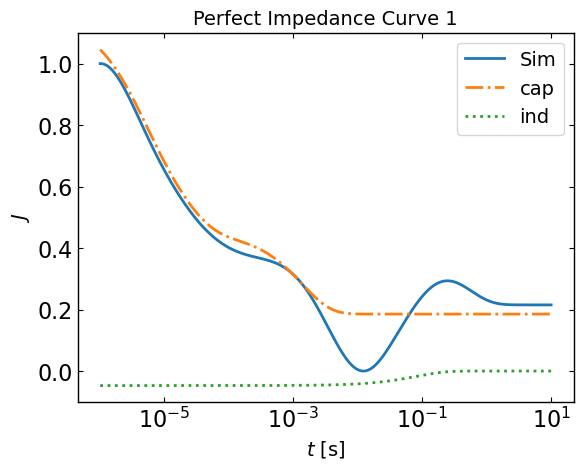

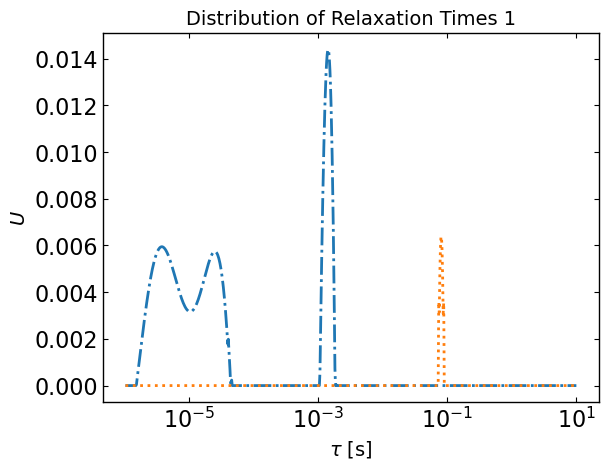

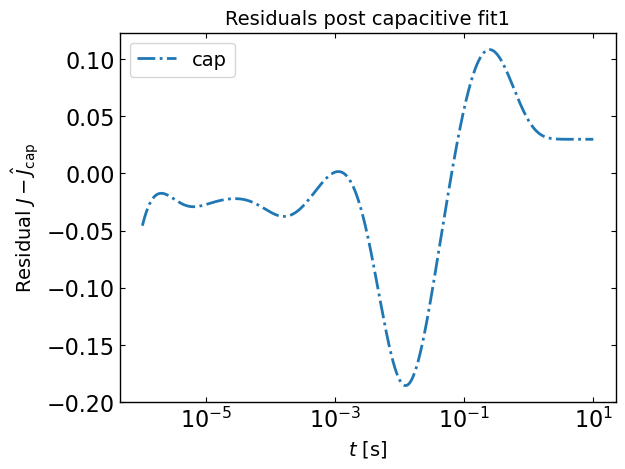

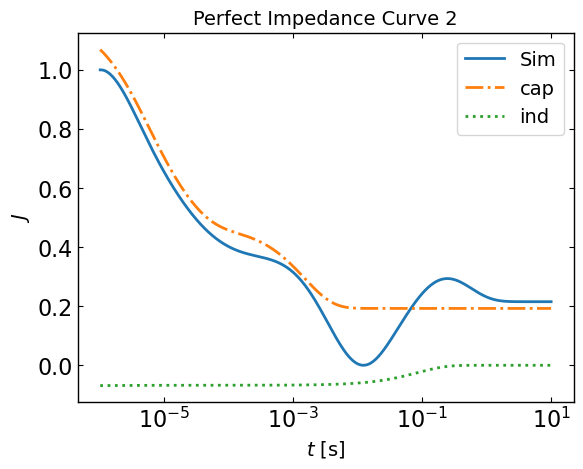

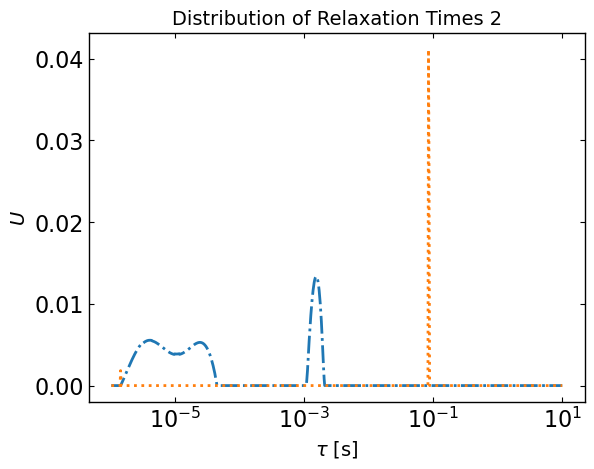

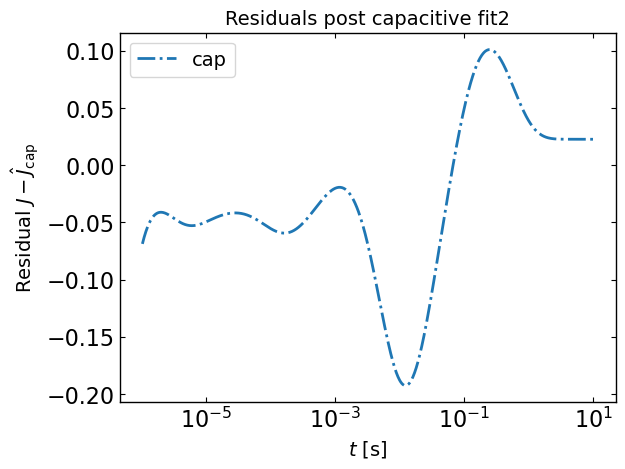

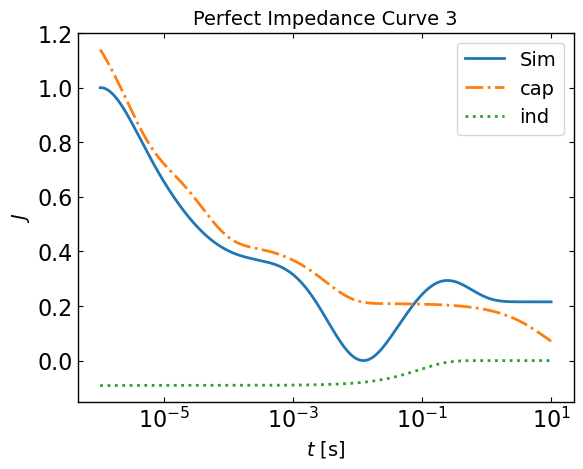

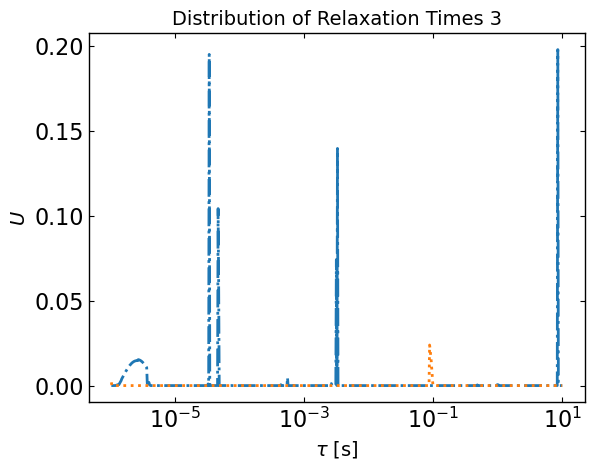

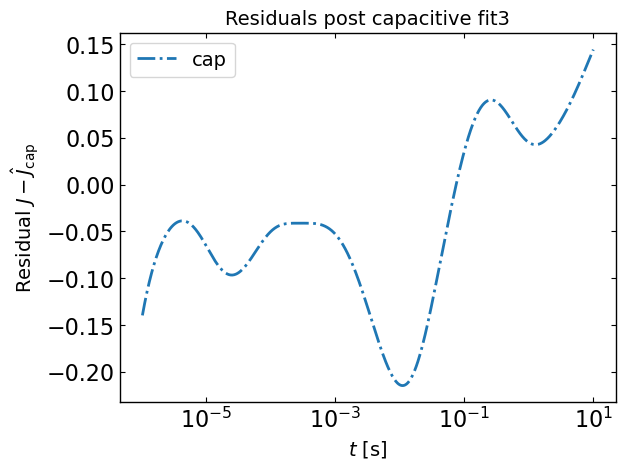

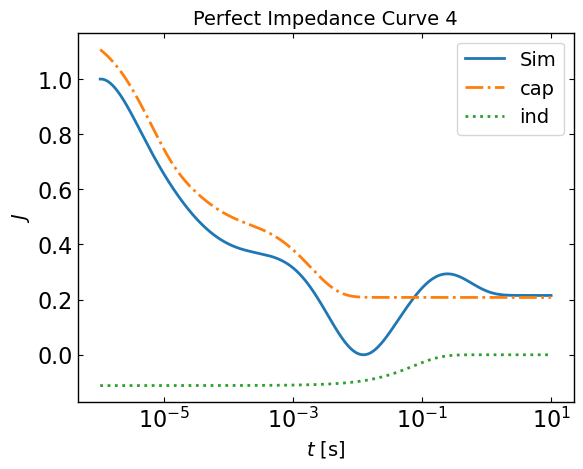

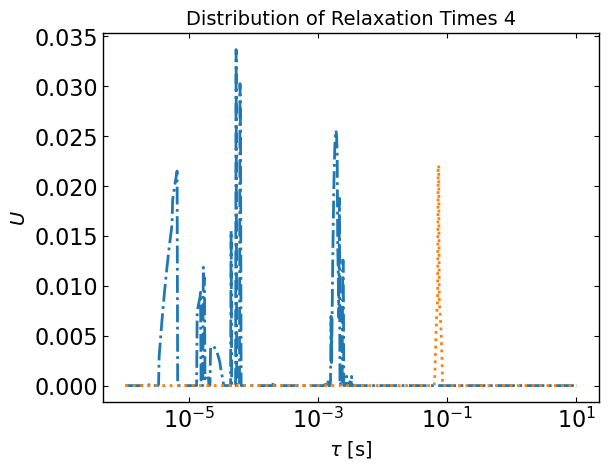

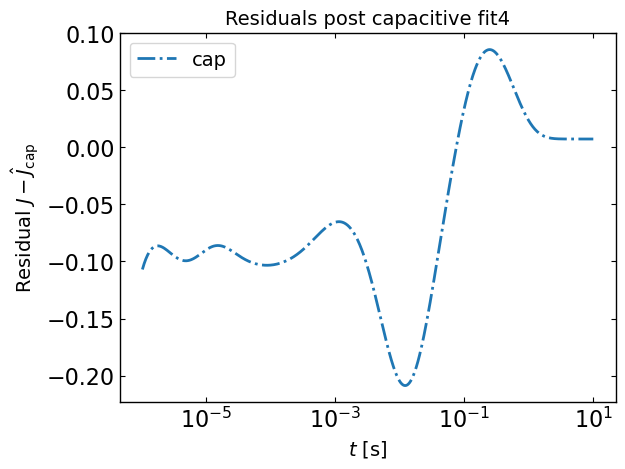

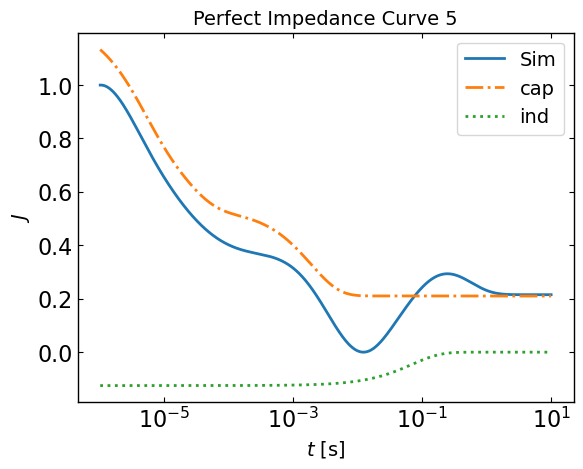

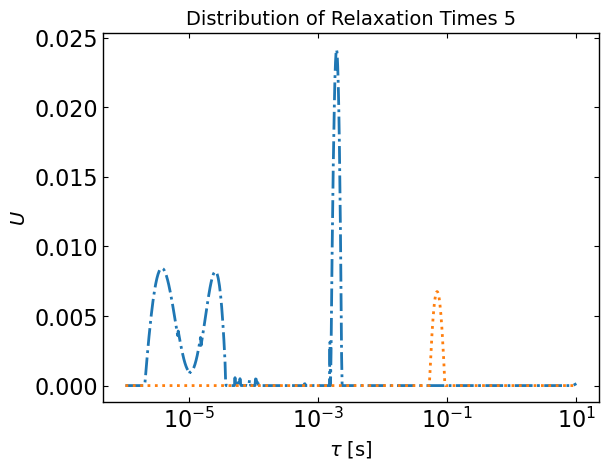

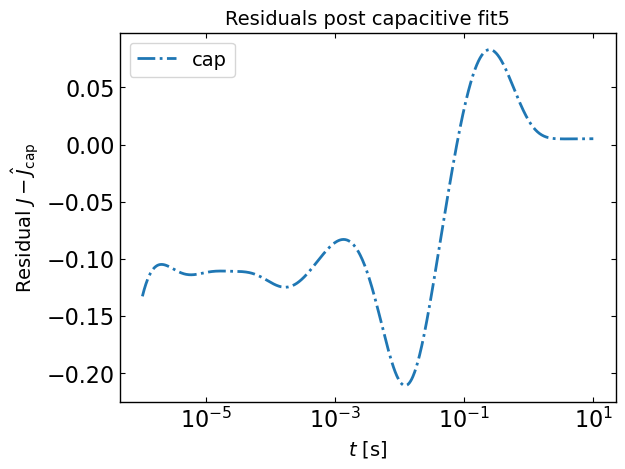

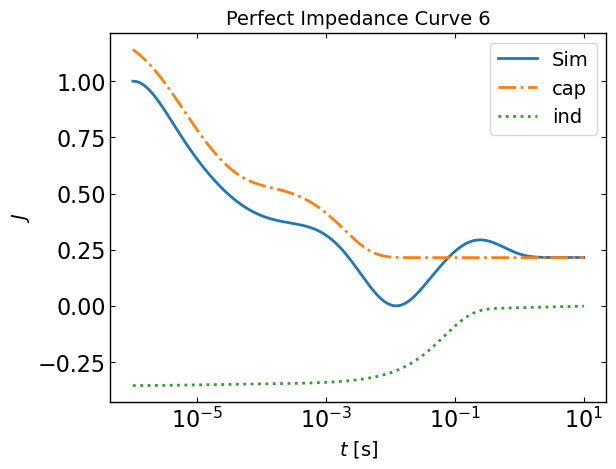

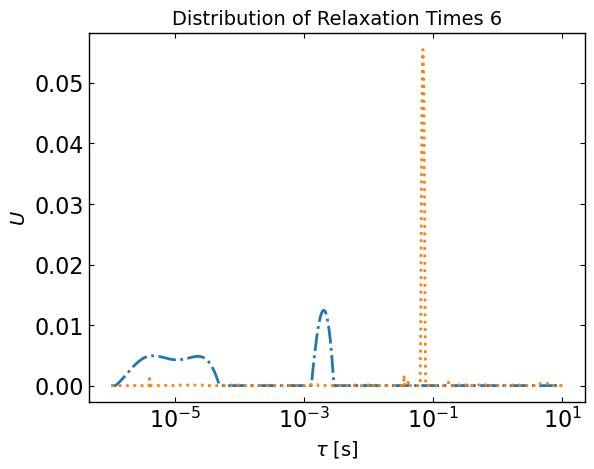

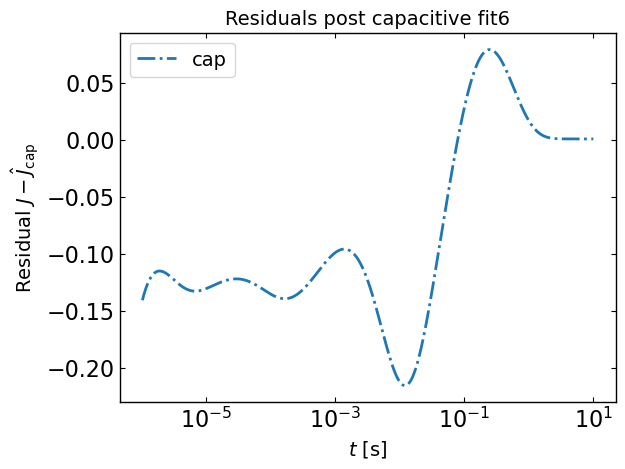

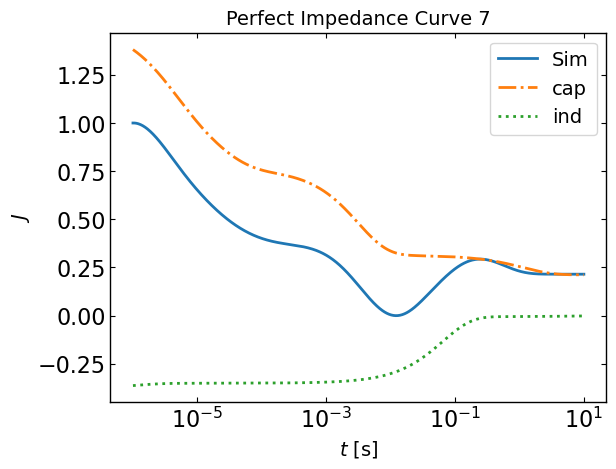

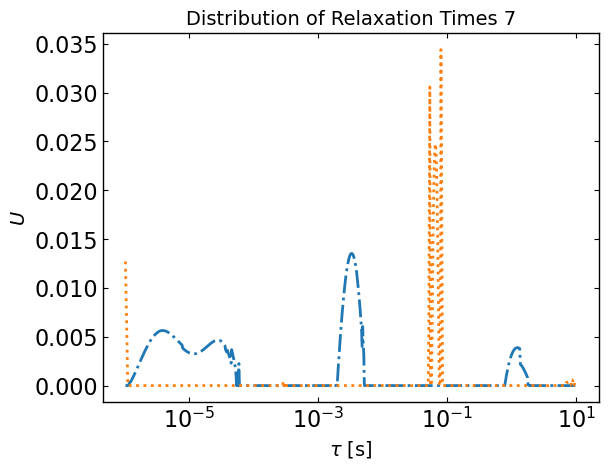

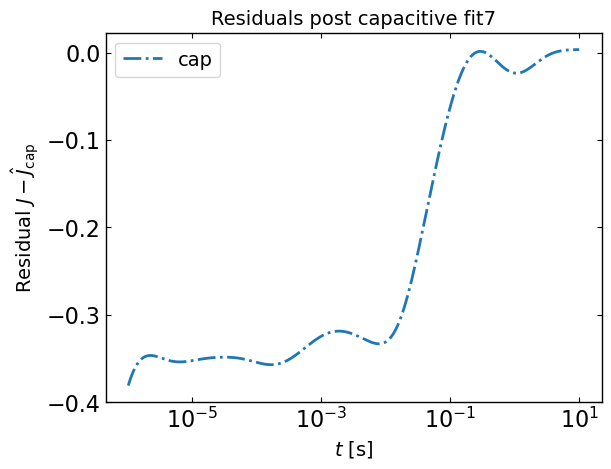

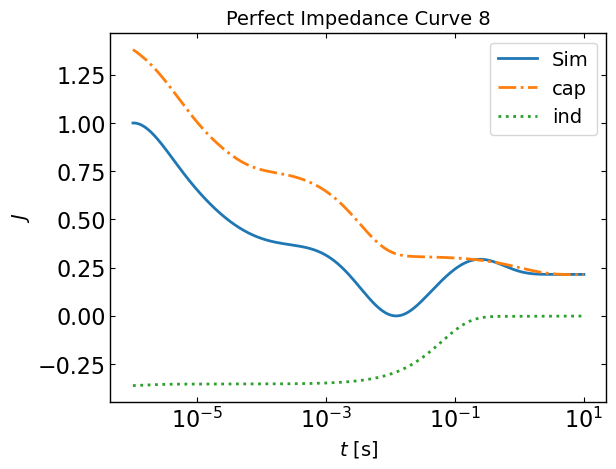

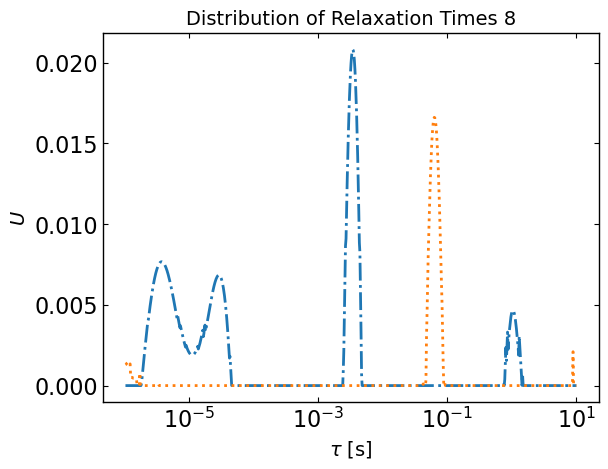

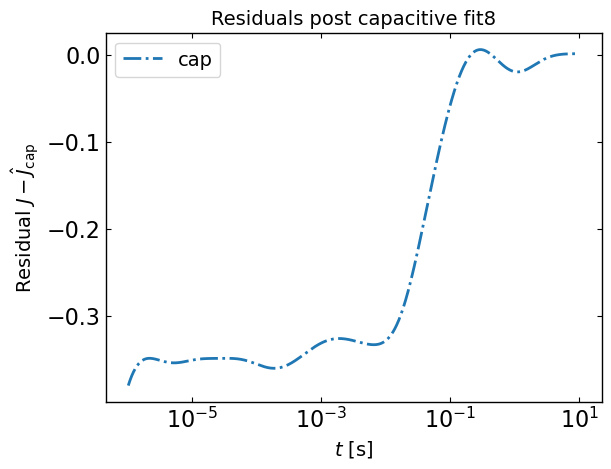

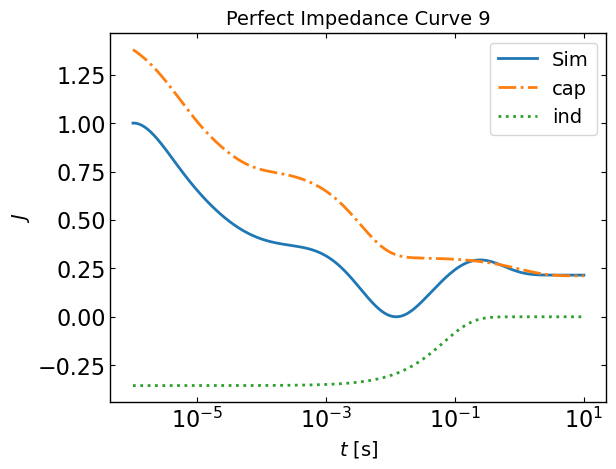

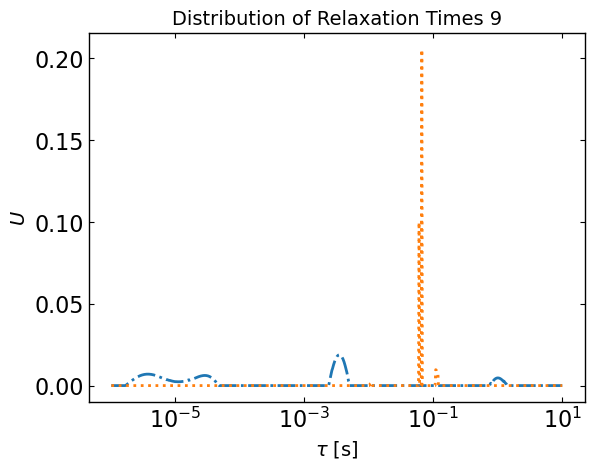

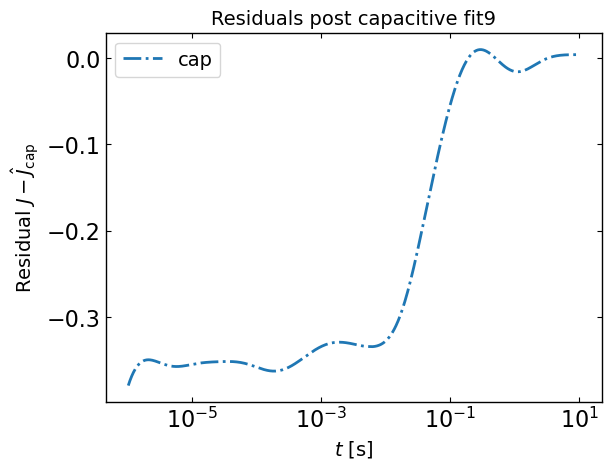

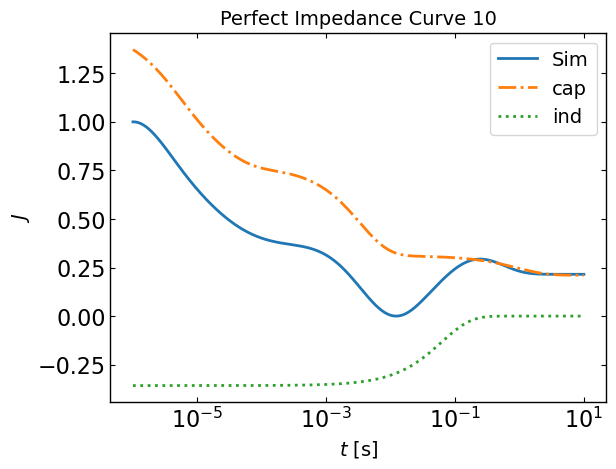

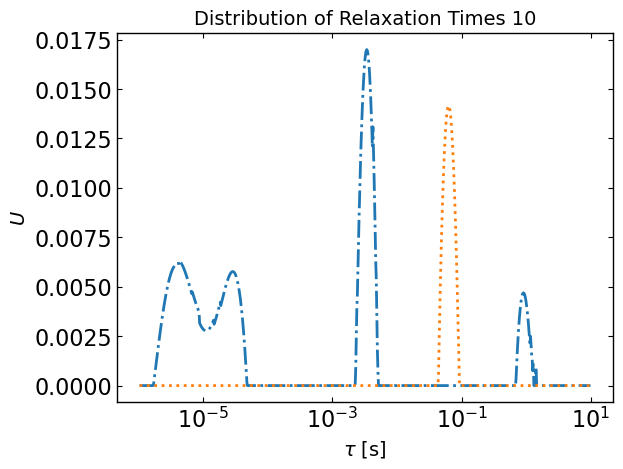

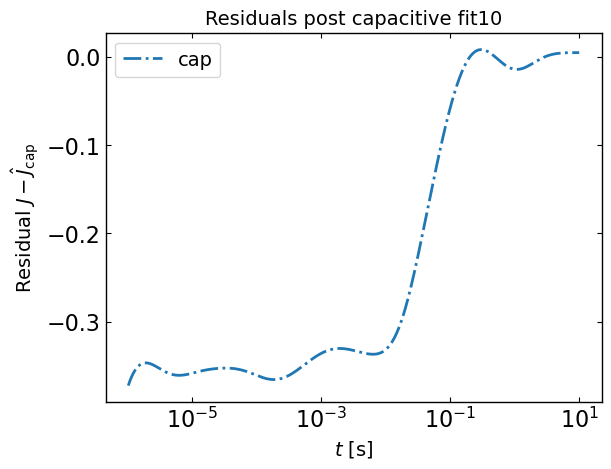

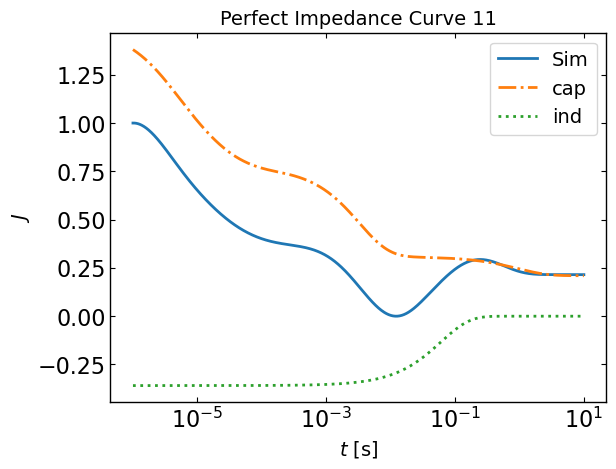

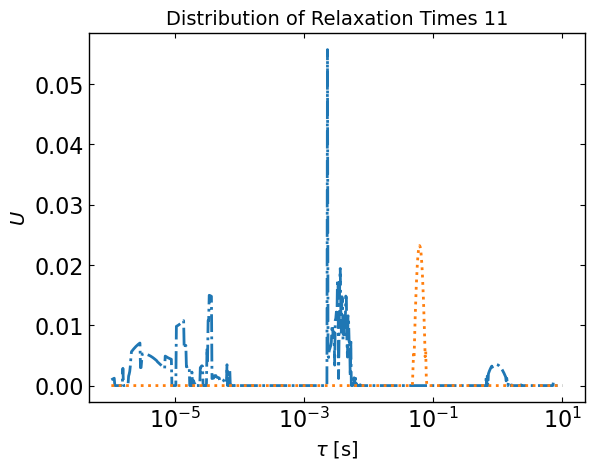

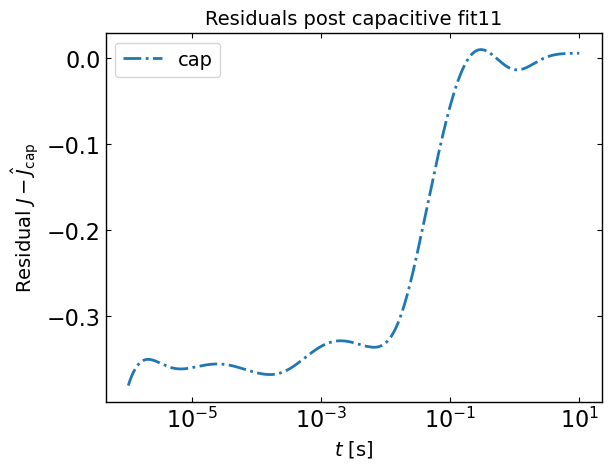

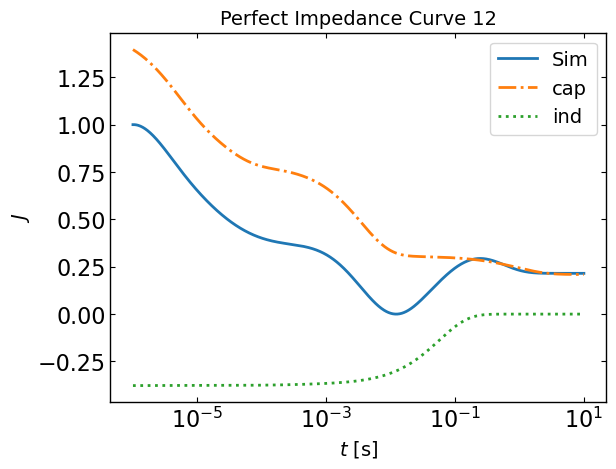

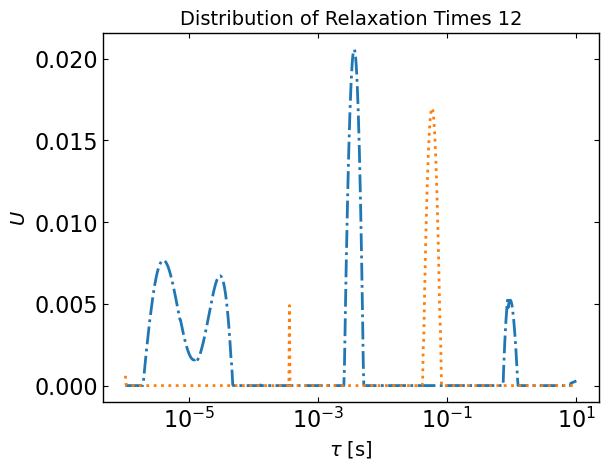

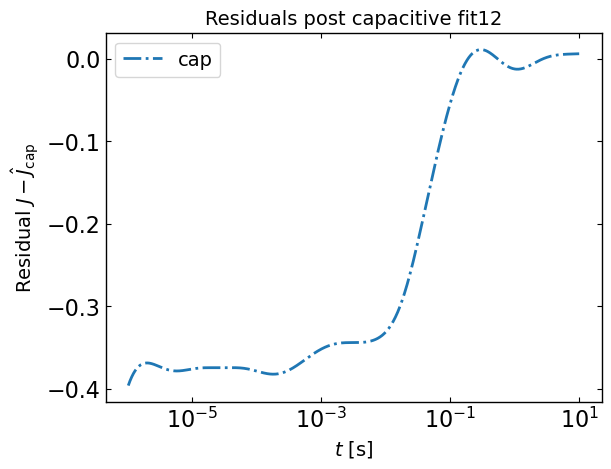

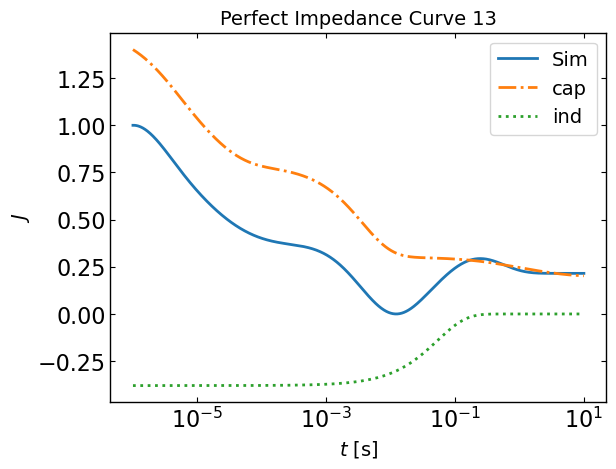

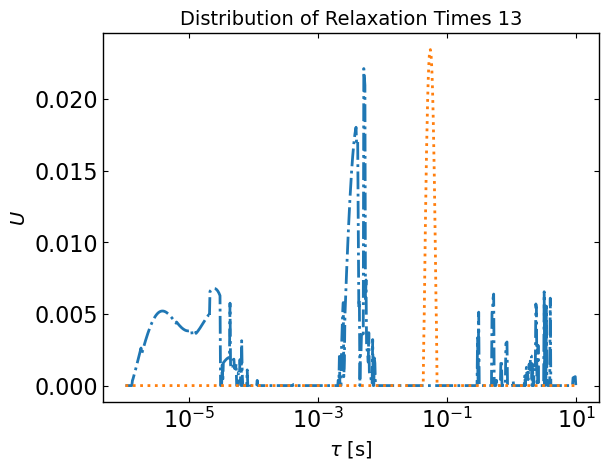

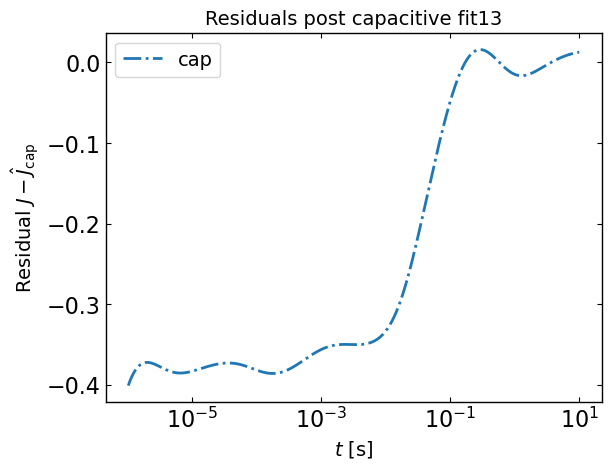

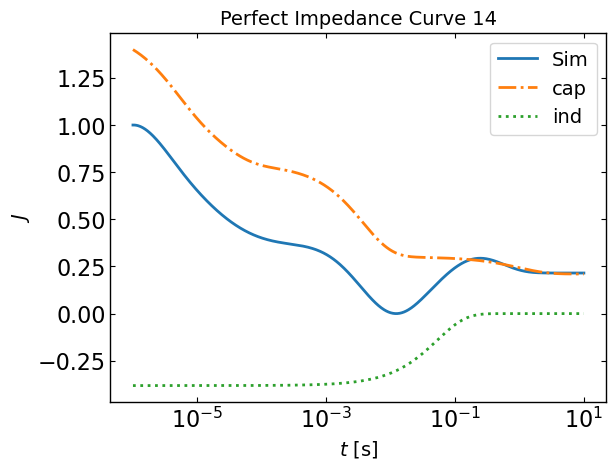

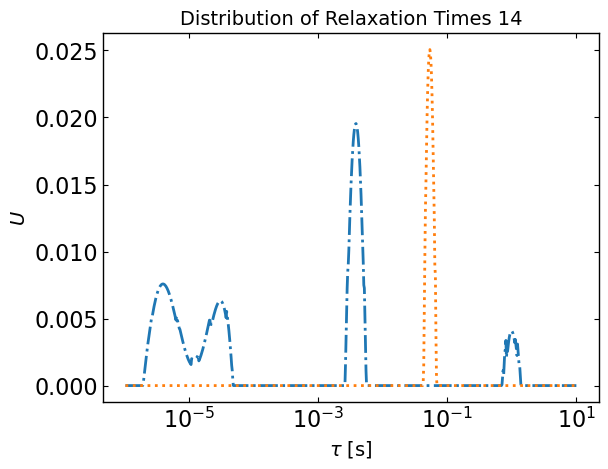

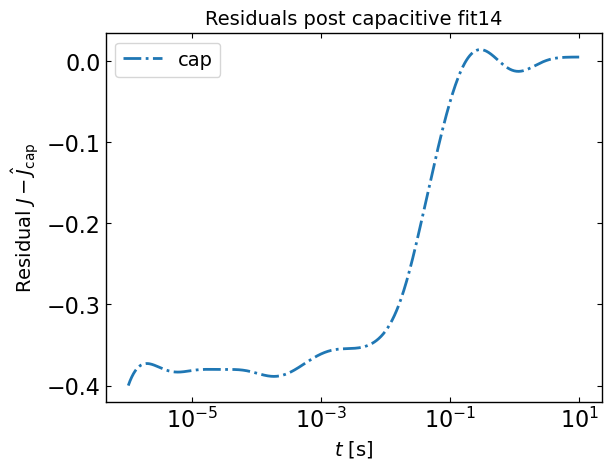

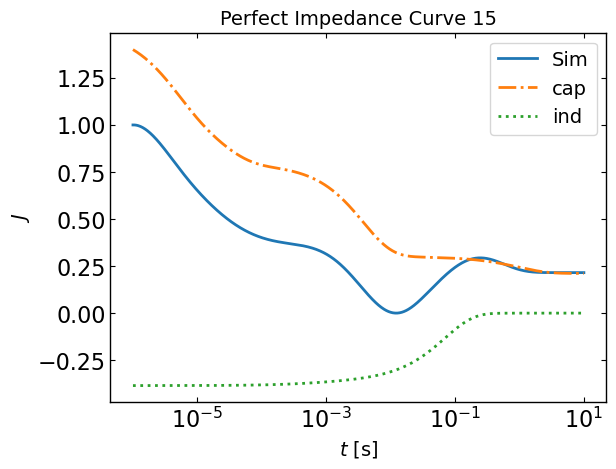

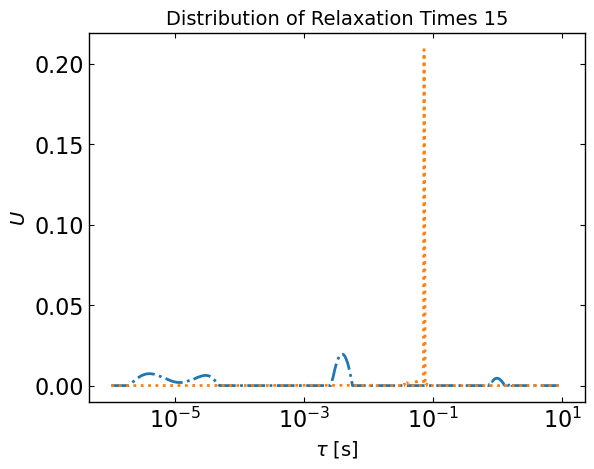

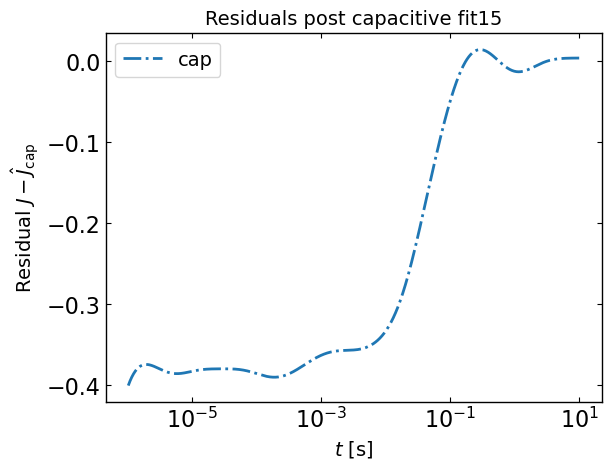

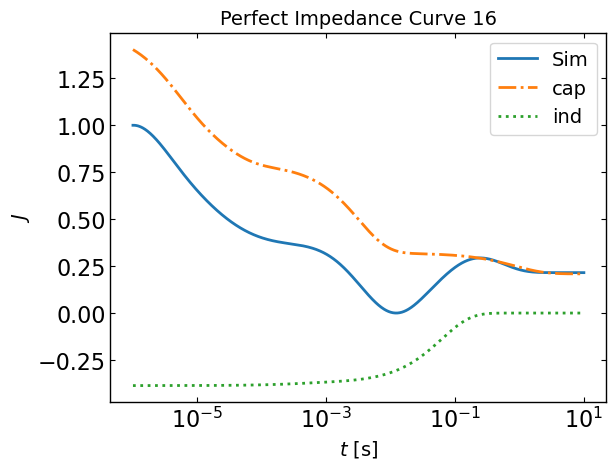

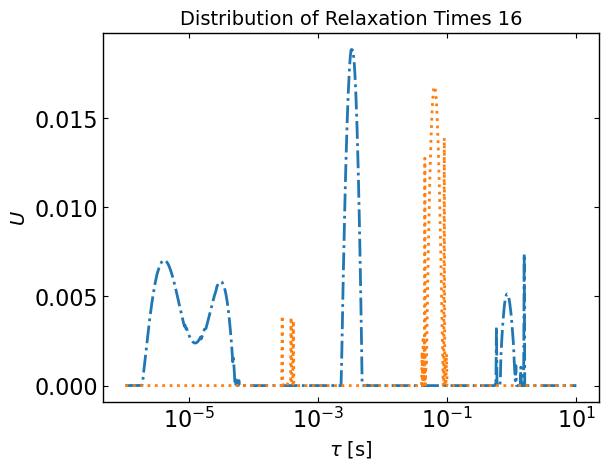

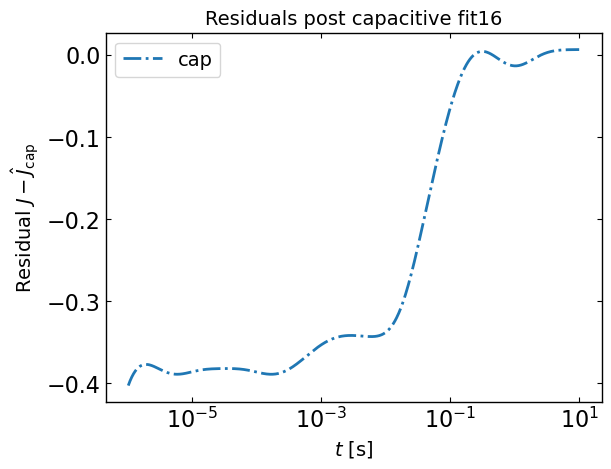

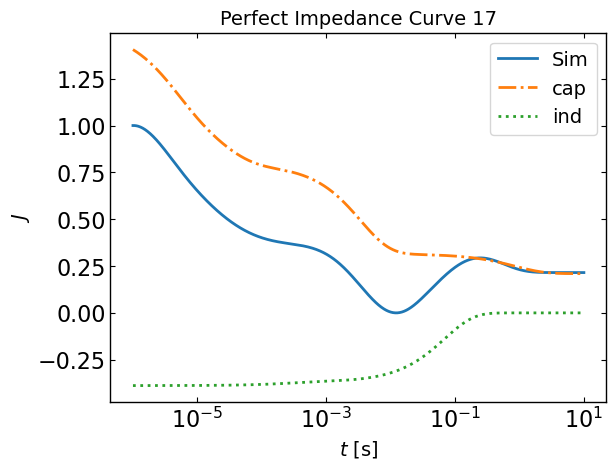

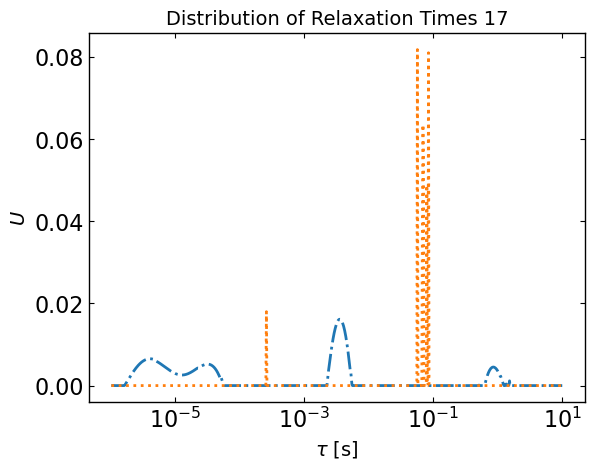

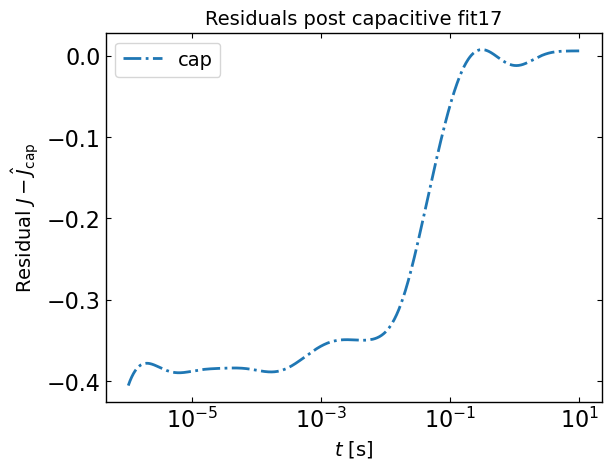

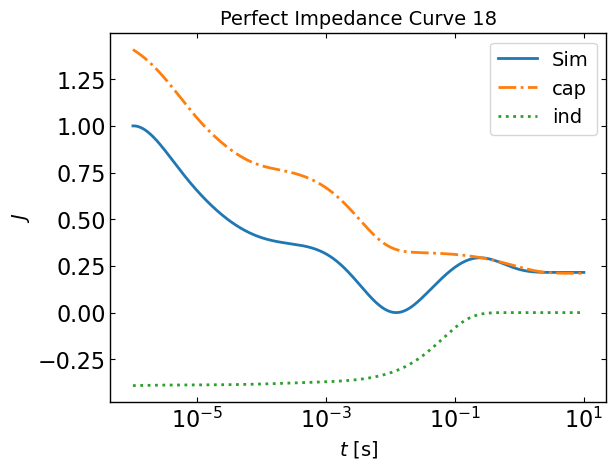

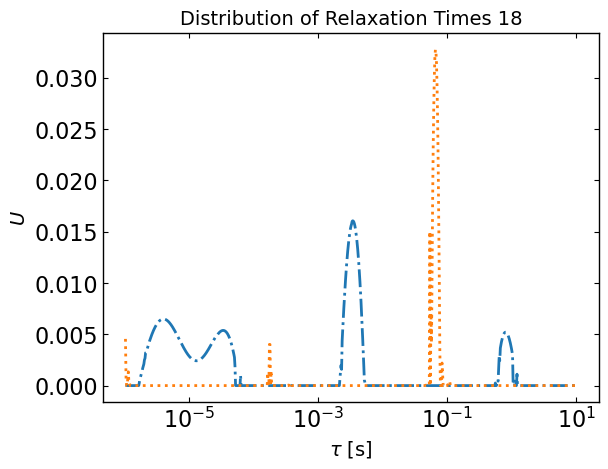

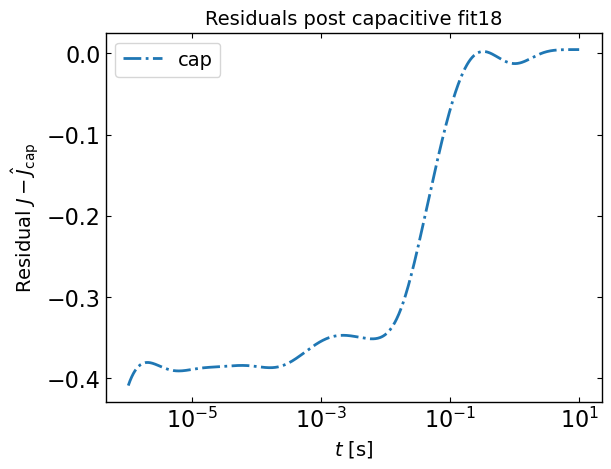

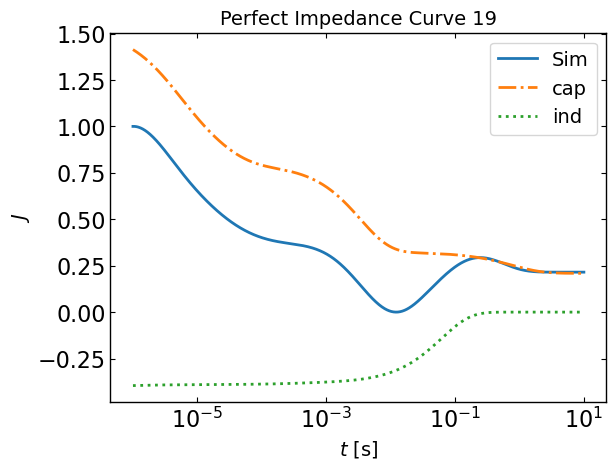

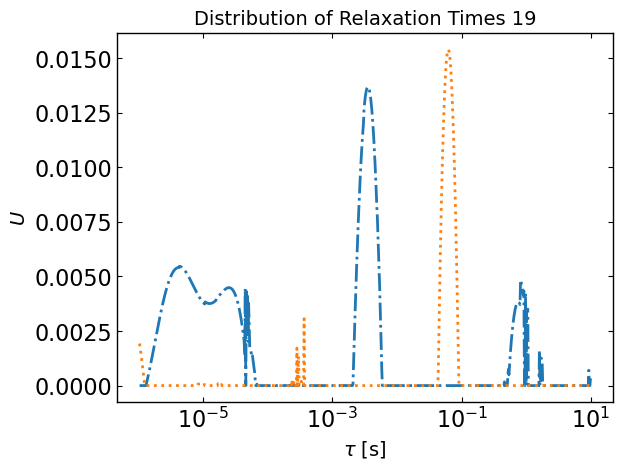

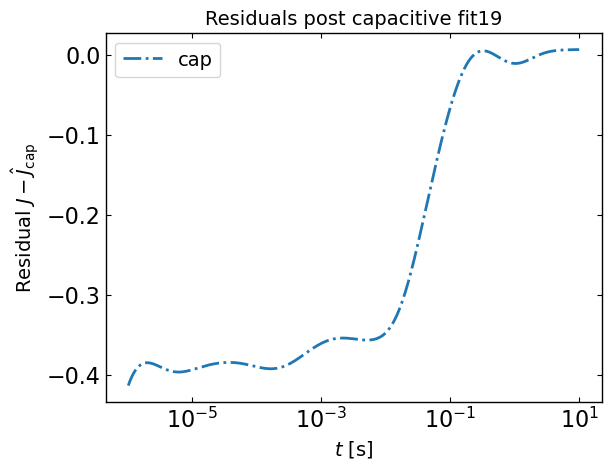

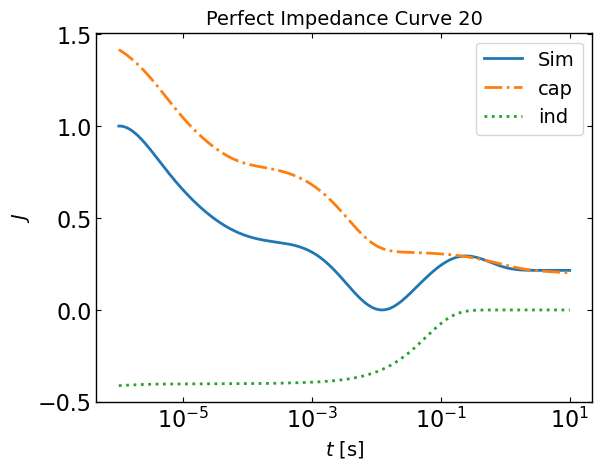

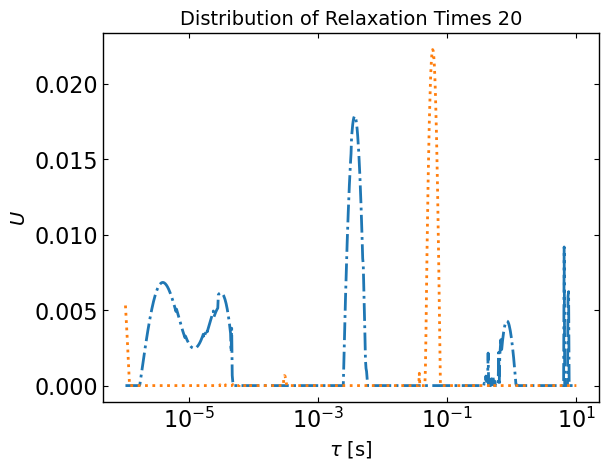

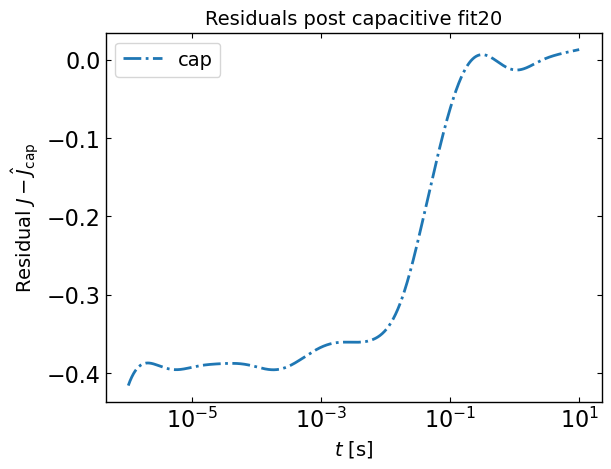

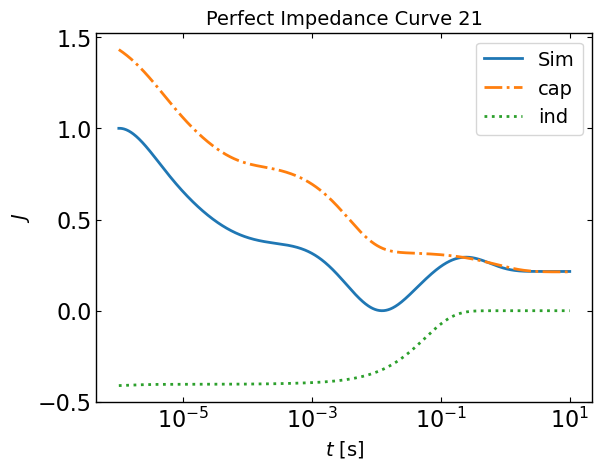

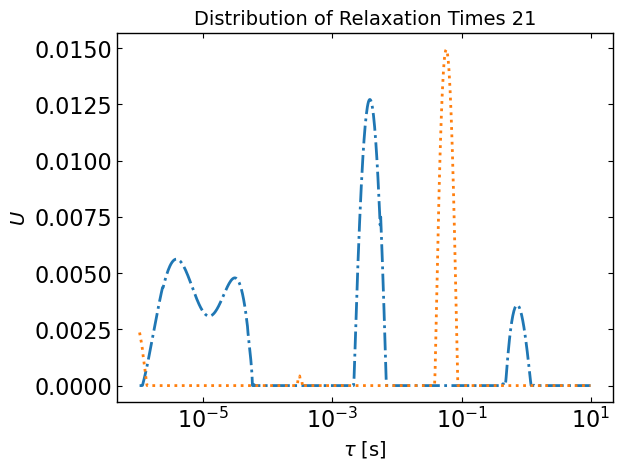

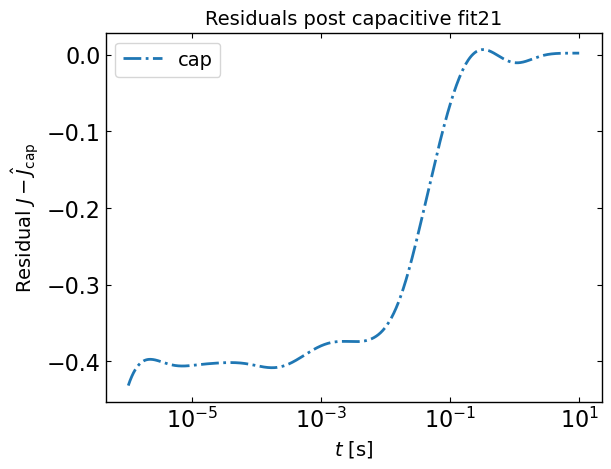

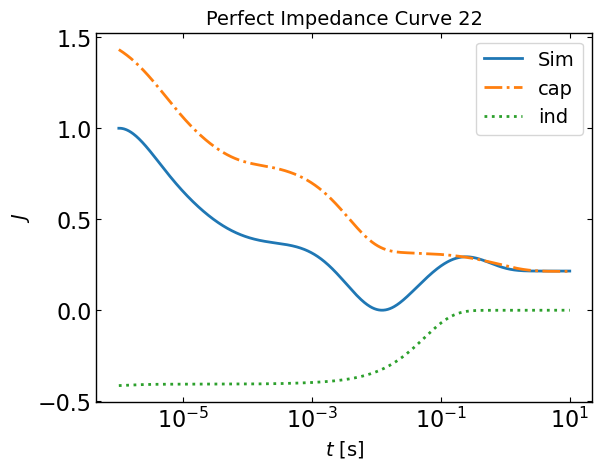

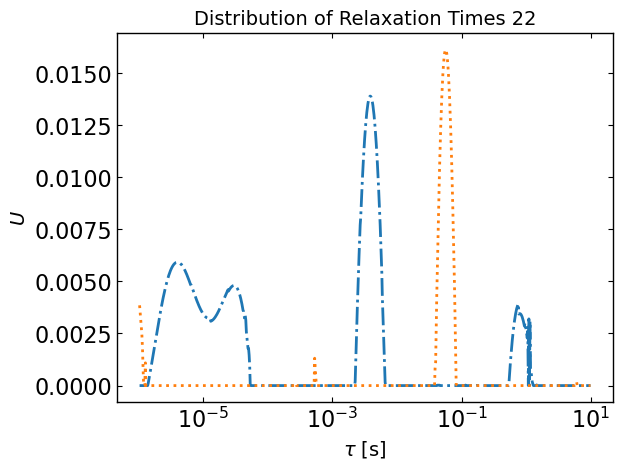

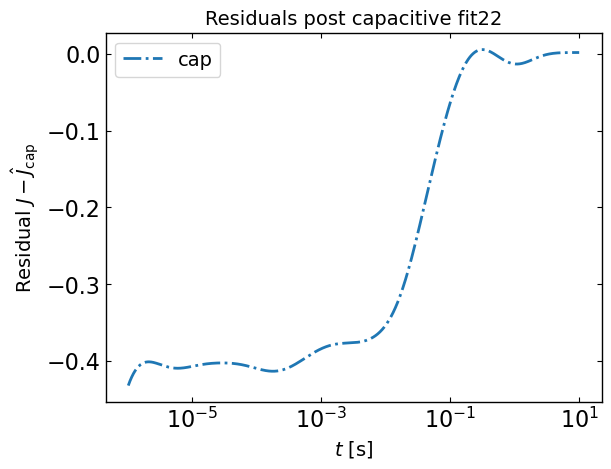

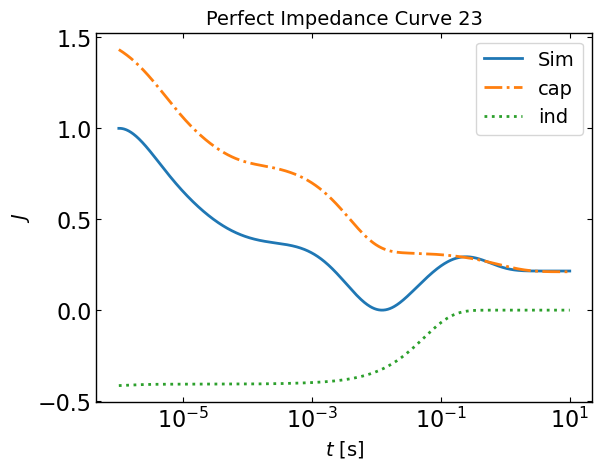

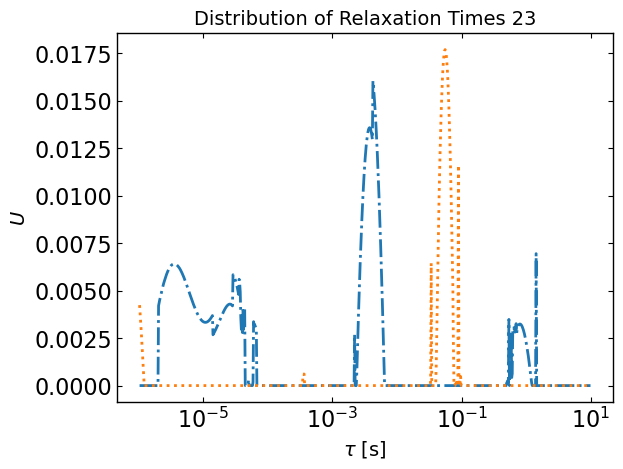

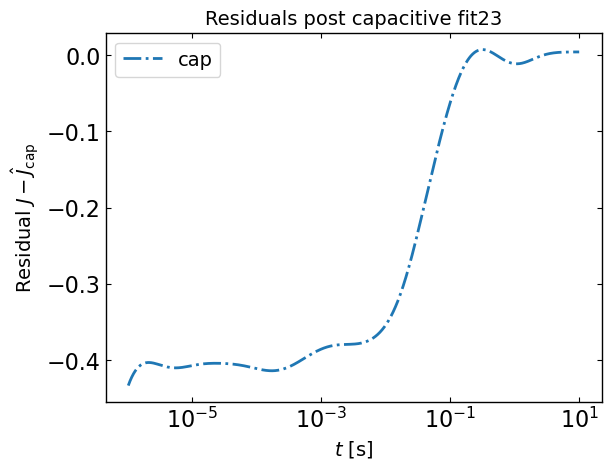

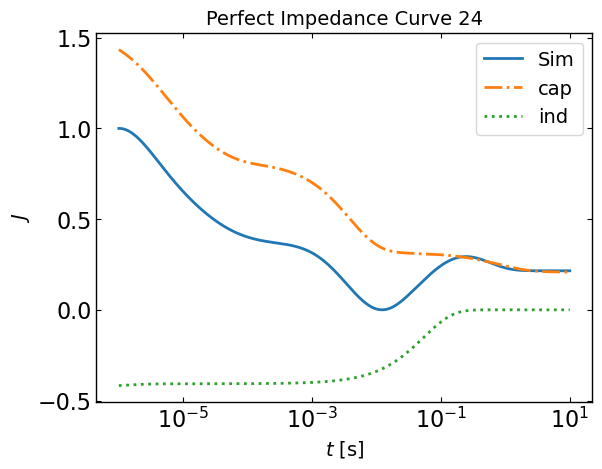

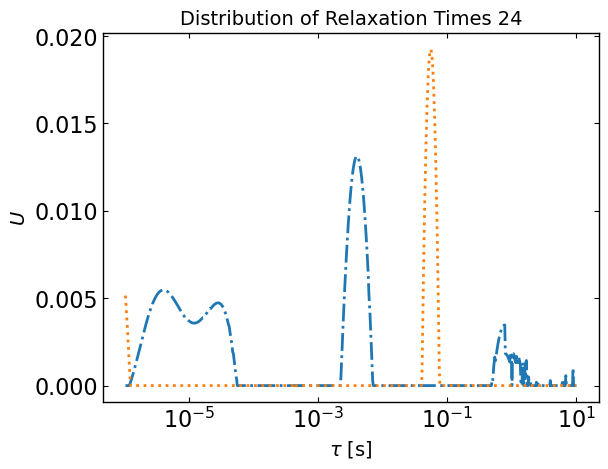

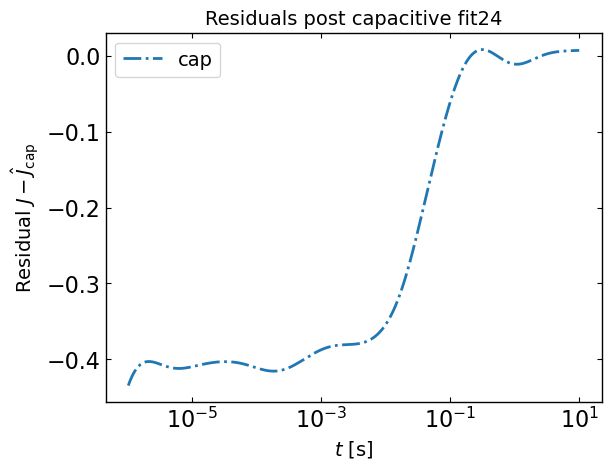

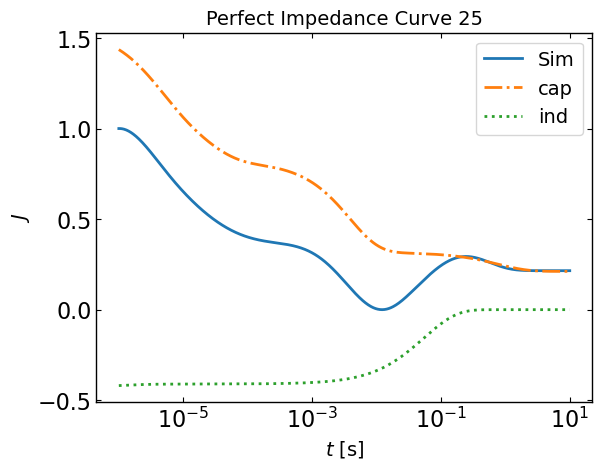

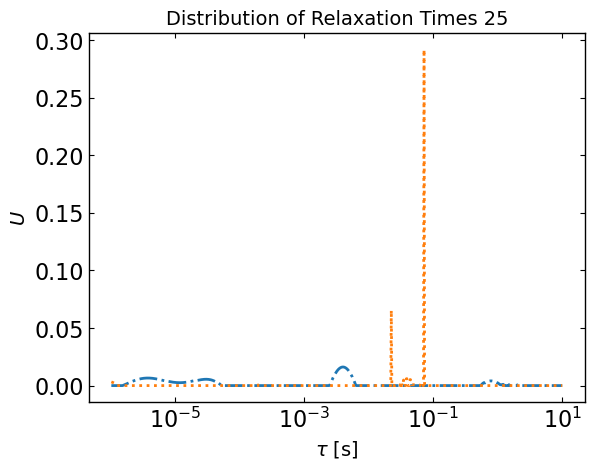

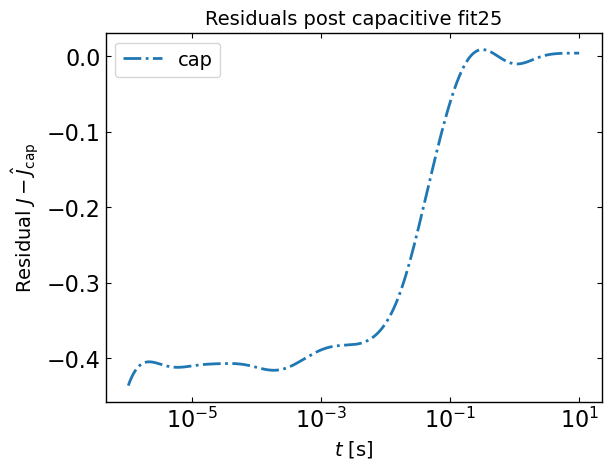

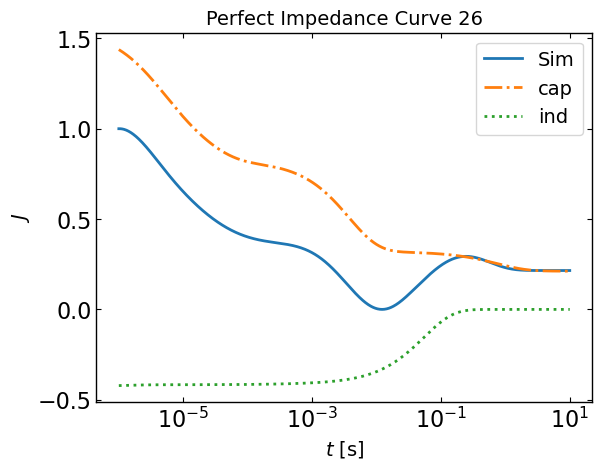

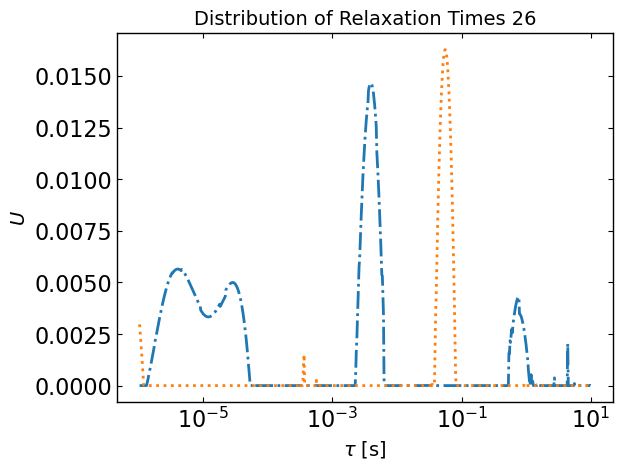

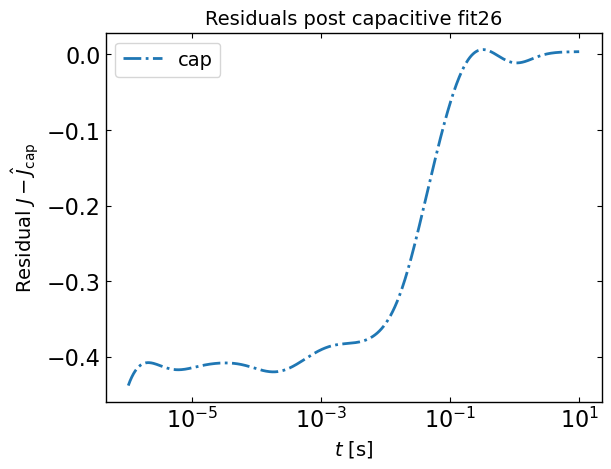

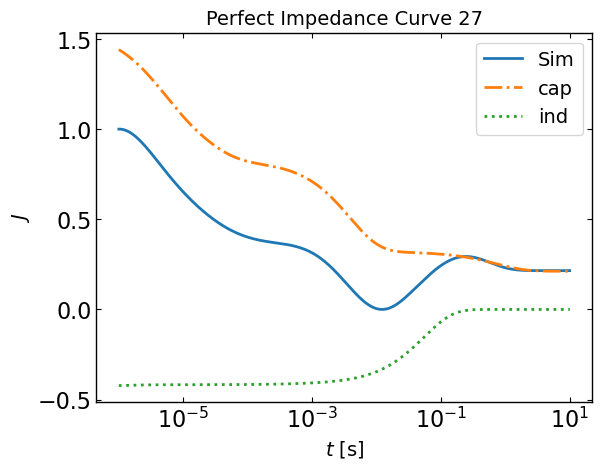

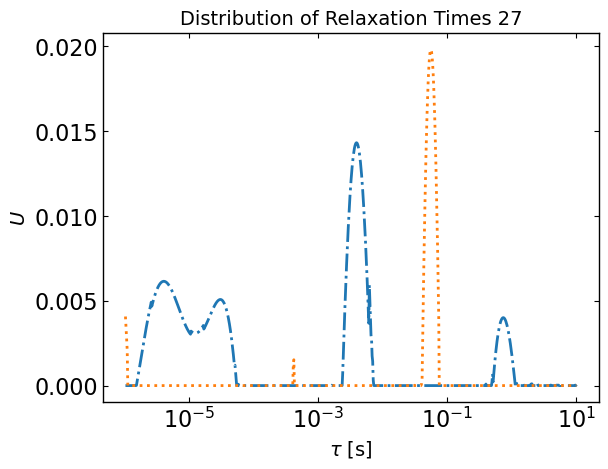

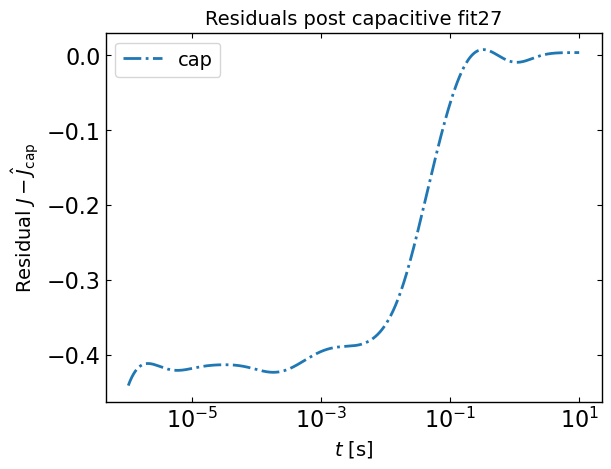

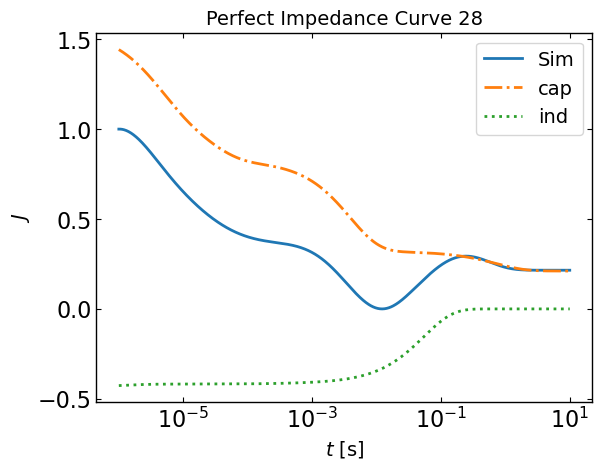

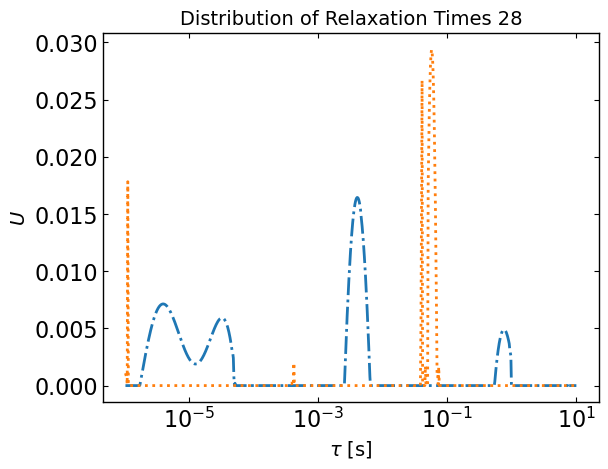

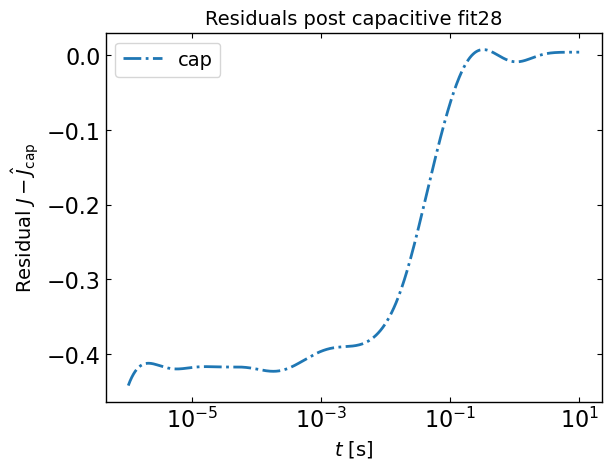

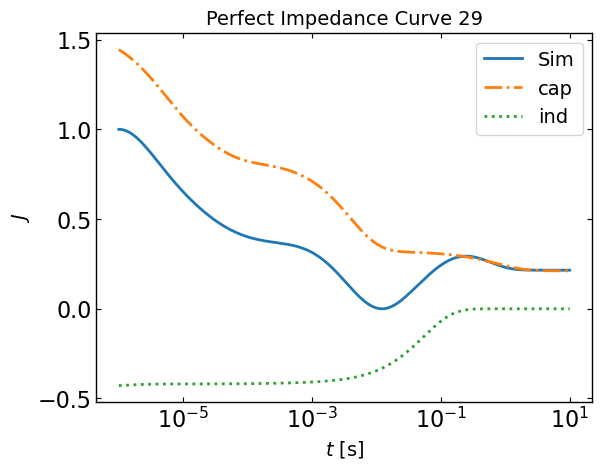

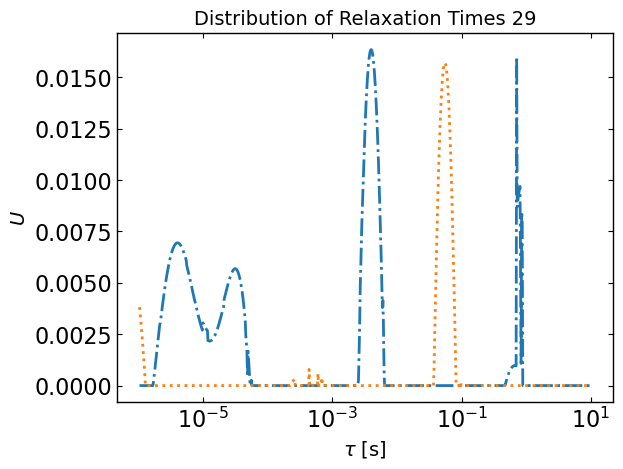

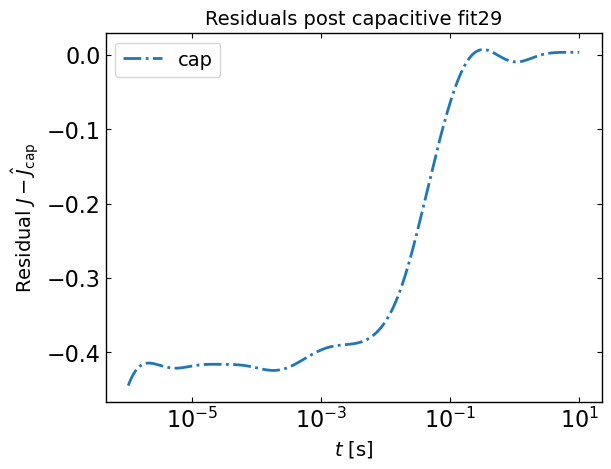

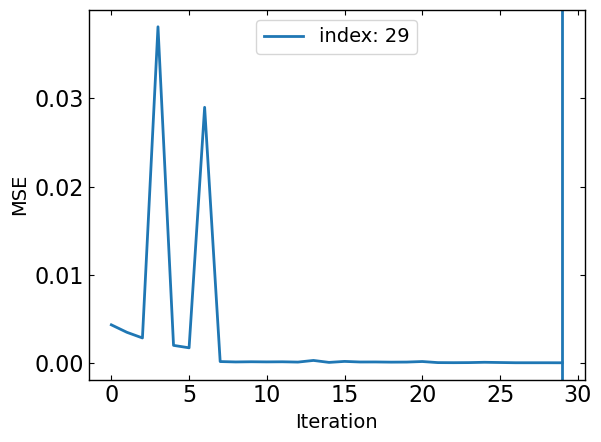

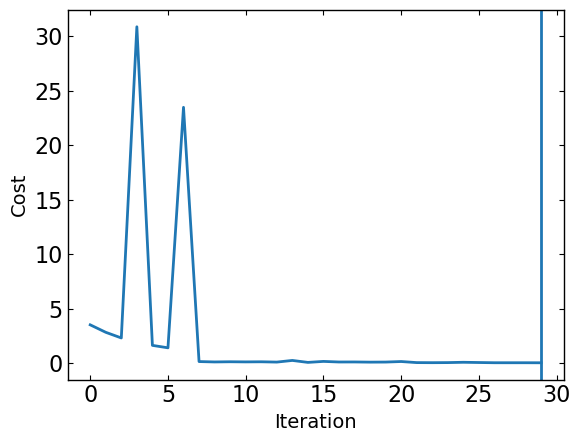

In [15]:
# Try running with old code 
old_checkerboard_fits = fit_DRT_curve_checkerboard(time, current_scaled, time, max_iter=200)

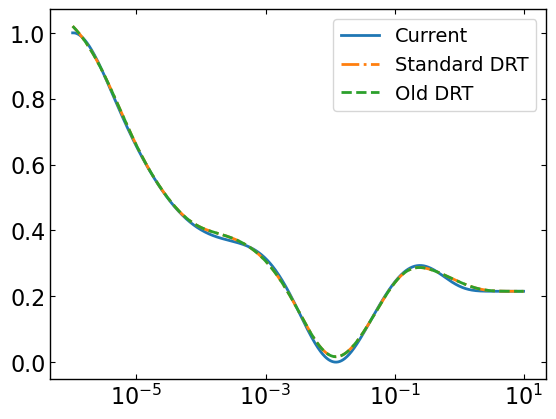

In [16]:
# Compare minimum MSE plots in both cases
old_MSE = [np.mean((fit.DRT_curve - current_scaled)**2) for fit in old_checkerboard_fits]
old_standard_fit_min_MSE = old_checkerboard_fits[np.argmin(old_MSE)]


# Plot fitted curves 
plt.plot(time, current_scaled, label='Current')
plt.plot(time, standard_fit_min_MSE.y, label='Standard DRT', linestyle='-.')
plt.plot(time, old_standard_fit_min_MSE.DRT_curve, linestyle='--', label="Old DRT")
plt.xscale('log')
plt.legend()
plt.show()

In [17]:
print(np.min(old_MSE))

5.035385101222618e-05


In [18]:
print(np.min(MSE))

5.035385101222618e-05


## Resolution to fitting issue
It turns out, the convergence criteria contained within each epoch of the fit_DRT_curve_linear_torch was the missing link - that and running the simulator for max 10 epochs per fit - resolved the poor fit issue.

## Trying the same fit but removing tau before fitting

In [19]:
trimmed_tau = time[:-time_ppd]

pre_trimmed_fits = drt.checkerboard_fit(time, current_scaled, trimmed_tau, max_fit_iter=200)

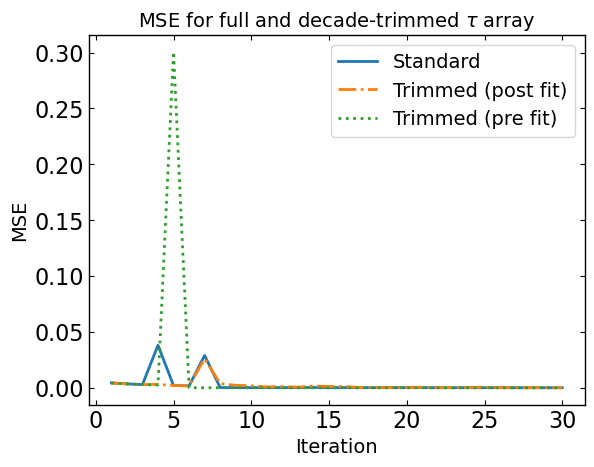

In [20]:
# Calcualte the MSE for curves with all tau values 
pre_trimmed_fits_MSE = [np.mean((fit.y - current_scaled)**2) for fit in pre_trimmed_fits]

plt.plot(range(1, len(checkerboard_fits)+1), MSE, label='Standard')
plt.plot(range(1, len(checkerboard_fits)+1), trimmed_fits_MSE, linestyle = '-.', label='Trimmed (post fit)')
plt.plot(range(1, len(checkerboard_fits)+1), pre_trimmed_fits_MSE, linestyle = ':', label='Trimmed (pre fit)')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title("MSE for full and decade-trimmed $\\tau$ array ")
plt.legend()
plt.show()

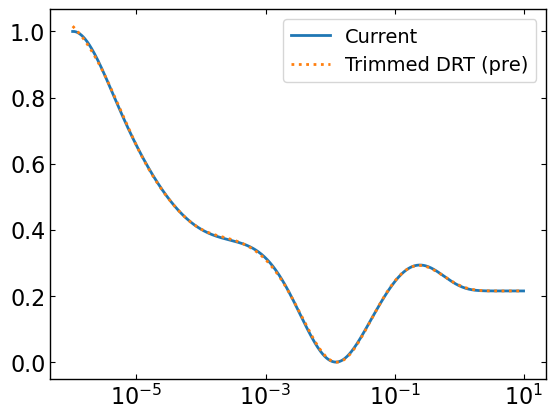

In [21]:
# Find the minimum MSE index for trimming pre-fit
pre_trimmed_fit_min_MSE = pre_trimmed_fits[np.argmin(pre_trimmed_fits_MSE)]

# Plot fitted curves 
plt.plot(time, current_scaled, label='Current')
# plt.plot(time, trimmed_fit_min_MSE.y, label='Trimmed DRT (post)', linestyle='-.')
# plt.plot(time, standard_fit_min_MSE.y, label='Standard DRT', linestyle='--')
plt.plot(time, pre_trimmed_fit_min_MSE.y, label='Trimmed DRT (pre)', linestyle=':')
plt.xscale('log')
plt.legend()
plt.show()


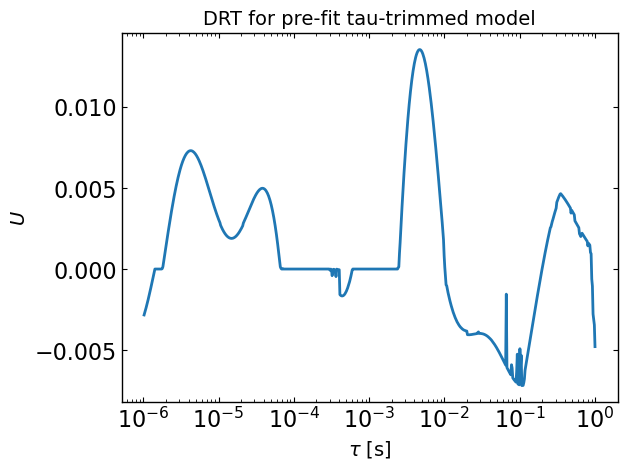

In [22]:
# Plot pre-fit trimmed tau DRT
plt.plot(trimmed_tau, pre_trimmed_fit_min_MSE.U)
plt.xscale("log")
plt.xlabel("$\\tau$ [s]")
plt.ylabel("$U$")
plt.title("DRT for pre-fit tau-trimmed model")
plt.show()

## Applying both lower tau and upper tau limits


In [23]:
# Define a new tau set 
tau_min = 1/np.pi * (time[1] - time[0])
tau_max = time[-time_ppd]
tau_decades = int(np.log10(tau_max/tau_min))
limited_tau_values = np.geomspace(tau_min, tau_max, time_ppd*tau_decades)

In [24]:
# Pre trimmed fits
limited_fits = drt.checkerboard_fit(time, current_scaled, limited_tau_values, max_fit_iter=100, checkerboard_iter=70)

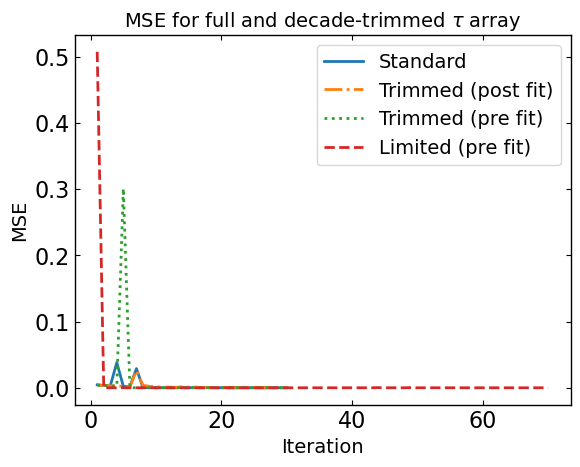

In [25]:
# Calcualte the MSE for curves with all tau values 
limited_fits_MSE = [np.mean((fit.y - current_scaled)**2) for fit in limited_fits]

plt.plot(range(1, len(checkerboard_fits)+1), MSE, label='Standard')
plt.plot(range(1, len(checkerboard_fits)+1), trimmed_fits_MSE, linestyle = '-.', label='Trimmed (post fit)')
plt.plot(range(1, len(checkerboard_fits)+1), pre_trimmed_fits_MSE, linestyle = ':', label='Trimmed (pre fit)')
plt.plot(range(1, len(limited_fits)+1), limited_fits_MSE, linestyle = '--', label='Limited (pre fit)')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title("MSE for full and decade-trimmed $\\tau$ array ")
plt.legend()
plt.show()

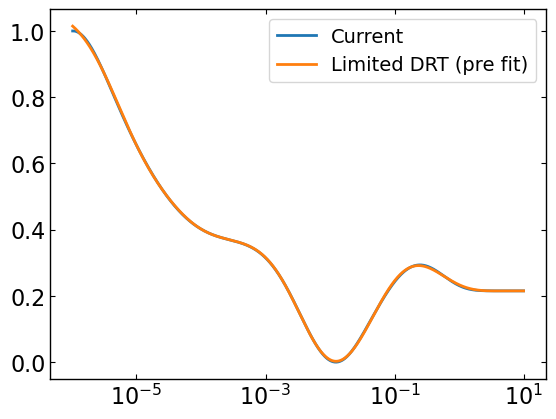

In [26]:
# Find the minimum MSE index for trimming pre-fit
limited_fit_min_MSE = limited_fits[np.argmin(limited_fits_MSE)]

# Plot fitted curves 
plt.plot(time, current_scaled, label='Current')
# plt.plot(time, trimmed_fit_min_MSE.y, label='Trimmed DRT (post)', linestyle='-.')
# plt.plot(time, standard_fit_min_MSE.y, label='Standard DRT', linestyle='--')
# plt.plot(time, pre_trimmed_fit_min_MSE.y, label='Trimmed DRT (pre)', linestyle=':')
plt.plot(time, limited_fit_min_MSE.y, label='Limited DRT (pre fit)', linestyle='-')
plt.xscale('log')
plt.legend()
plt.show()

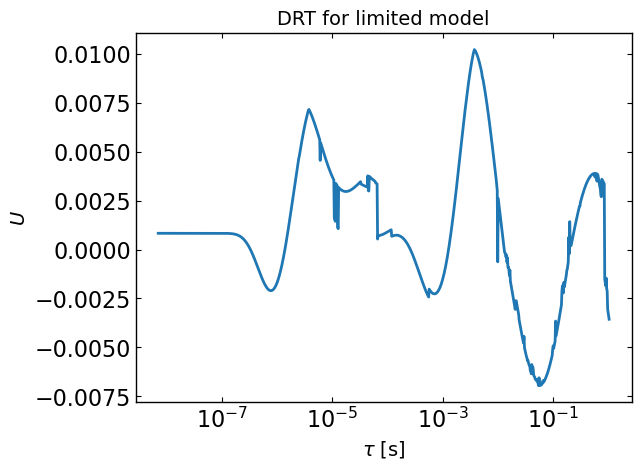

In [27]:
# Plot limited tau
plt.plot(limited_tau_values, limited_fit_min_MSE.U)
plt.xscale("log")
plt.xlabel("$\\tau$ [s]")
plt.ylabel("$U$")
plt.title("DRT for limited model")
plt.show()

## Introducing the lower time values suddenly, dramatically, clears up the signal
What happens if we are less strict with the end constraint? Rather than cutting off the last decade, we could cut off the values upto T/2pi

In [28]:
tau_max = (time[-1]-time[0])/(2*np.pi)
tau_decades = int(np.log10(tau_max/tau_min))

less_limited_tau_values = np.geomspace(tau_min, tau_max, time_ppd*tau_decades)

In [29]:
# Less limited tau fit
less_limited_fits = drt.checkerboard_fit(time, current_scaled, less_limited_tau_values, max_fit_iter=100, checkerboard_iter=150)

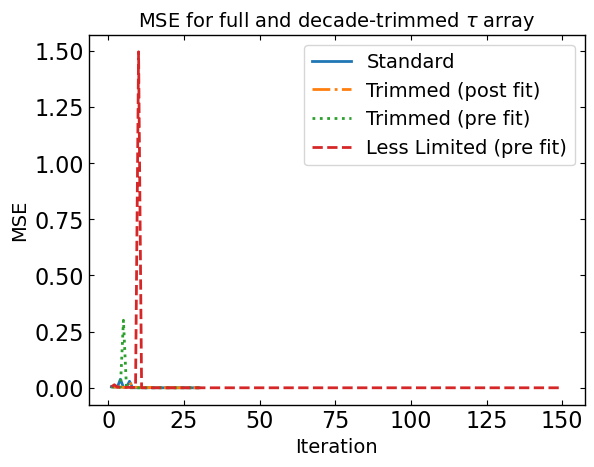

In [30]:
# Calcualte the MSE for curves with all tau values 
less_limited_fits_MSE = [np.mean((fit.y - current_scaled)**2) for fit in less_limited_fits]

plt.plot(range(1, len(checkerboard_fits)+1), MSE, label='Standard')
plt.plot(range(1, len(checkerboard_fits)+1), trimmed_fits_MSE, linestyle = '-.', label='Trimmed (post fit)')
plt.plot(range(1, len(checkerboard_fits)+1), pre_trimmed_fits_MSE, linestyle = ':', label='Trimmed (pre fit)')
plt.plot(range(1, len(less_limited_fits)+1), less_limited_fits_MSE, linestyle = '--', label='Less Limited (pre fit)')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title("MSE for full and decade-trimmed $\\tau$ array ")
plt.legend()
plt.show()

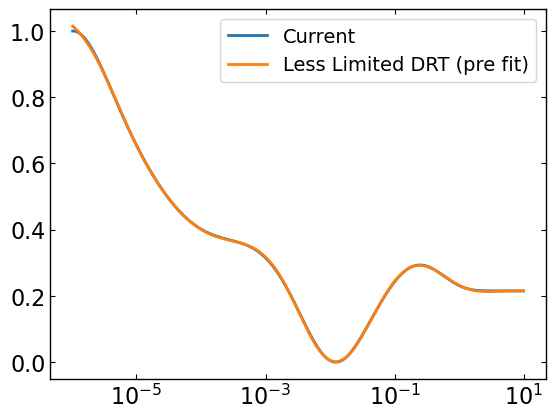

In [31]:
# Find the minimum MSE index for trimming pre-fit
less_limited_fit_min_MSE = less_limited_fits[np.argmin(less_limited_fits_MSE)]

# Plot fitted curves 
plt.plot(time, current_scaled, label='Current')
# plt.plot(time, trimmed_fit_min_MSE.y, label='Trimmed DRT (post)', linestyle='-.')
# plt.plot(time, standard_fit_min_MSE.y, label='Standard DRT', linestyle='--')
# plt.plot(time, pre_trimmed_fit_min_MSE.y, label='Trimmed DRT (pre)', linestyle=':')
plt.plot(time, less_limited_fit_min_MSE.y, label='Less Limited DRT (pre fit)', linestyle='-')
plt.xscale('log')
plt.legend()
plt.show()

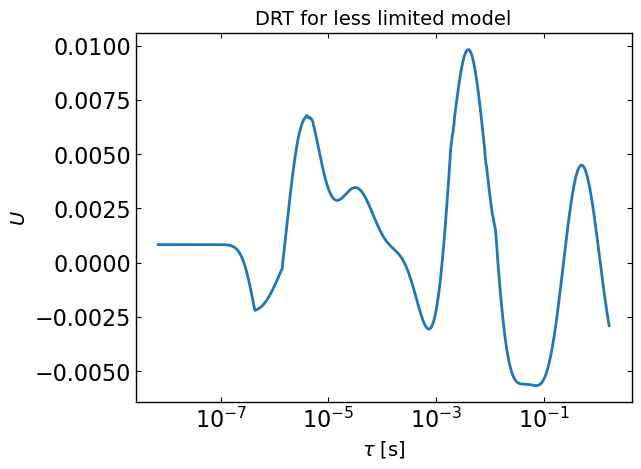

In [32]:
# Plot limited tau
plt.plot(less_limited_tau_values, less_limited_fit_min_MSE.U)
plt.xscale("log")
plt.xlabel("$\\tau$ [s]")
plt.ylabel("$U$")
plt.title("DRT for less limited model")
plt.show()

In [33]:
# Try the same thing with the new OSQP method 
osqp_checkerboard_fit = drt.osqp_checkerboard_fit(time, current_scaled, less_limited_tau_values, checkerboard_iters=150)

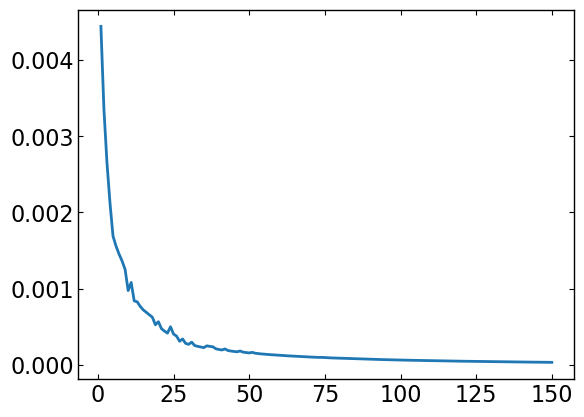

In [34]:
# Plot the fit error
MSE_values_osqp = [fit.cost for fit in osqp_checkerboard_fit]
plt.plot(range(1, len(MSE_values_osqp)+1), MSE_values_osqp)

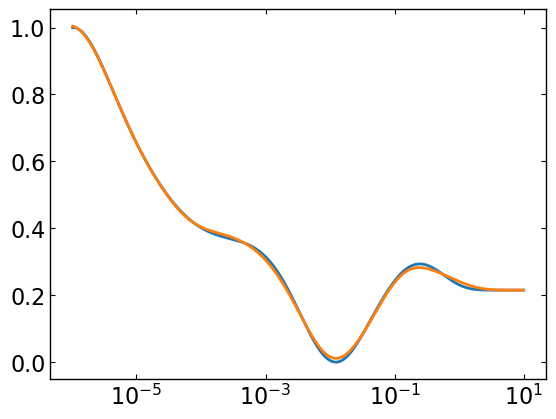

In [35]:
# test the new osqp checkerboard fit 
plt.plot(time, current_scaled)
plt.plot(time, osqp_checkerboard_fit[149].y)
plt.xscale('log')

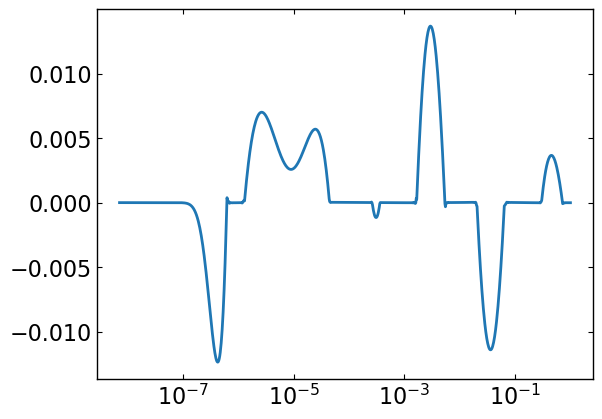

In [36]:
plt.plot(limited_tau_values, osqp_checkerboard_fit[149].U)
plt.xscale('log')